<a href="https://colab.research.google.com/github/sergiocostaifes/PPCOMP_DM/blob/main/notebooks/14_decision_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NB14 — Episódios, Antecipabilidade e Função de Custo

## 1. Papel deste notebook no pipeline

O NB14 conecta os escores produzidos nas etapas de modelagem à avaliação de antecipabilidade por episódio, lead time, falsos alertas por unidade de tempo e custo relativo associado ao limiar de alerta.

O NB10 estabeleceu os cenários temporalmente elegíveis e adotou `W5_K24_H12_P1_TRAIN_M2S` como cenário principal, com limiar de criticidade estimado no trecho de treino. O NB11 avaliou modelos supervisionados e baselines temporais, realizou o diagnóstico de calibração e materializou os escores usados nas análises subsequentes. O NB12 examinou a sensibilidade da escolha principal, especialmente em relação a `TRAIN_P95`. O NB13 avaliou a LSTM como análise sequencial complementar e manteve o modelo tabular vencedor do NB11 como fonte principal de escores.

A etapa não reabre a seleção de cenários nem o treinamento dos modelos. Sua função é examinar como o escore relativo de risco temporal pode apoiar a definição de alertas e a análise de custos sob incerteza. O NB14 não consome artefatos do NB13a.

## 2. Objetivo

O objetivo deste notebook é avaliar os escores produzidos pelo pipeline em termos de:

1. cobertura de episódios críticos;
2. antecedência dos alertas antes da entrada em `DURING`;
3. relação entre duração dos episódios e antecipabilidade;
4. falsos alertas por unidade de tempo;
5. limiares de alerta `tau` sob diferentes relações de custo entre falsos positivos e falsos negativos.

A etapa aproxima as métricas preditivas de uma leitura de Pesquisa Operacional: o escore `s(x)` informa uma regra de alerta por limiar e permite comparar consequências relativas de diferentes configurações, sem constituir por si só uma política operacional validada.

## 3. Entradas esperadas

Este notebook consome artefatos primários produzidos pelas etapas anteriores.

### 3.1 Entradas do NB10

- `10_scenario_episodes.parquet`;
- `10_scenario_series_states.parquet`;
- `10_scenario_decisions.csv`, quando disponível.

Esses arquivos fornecem a estrutura dos episódios críticos, os estados operacionais, a granularidade temporal, o horizonte `H`, a persistência mínima e a identificação dos cenários.

### 3.2 Entradas do NB11

- `11_winner_model.json`;
- `11_nb11_summary.json`;
- `11_scores_calibrated.parquet`, preferencialmente;
- `11_scores_raw.parquet`, como alternativa;
- `11_calibration_summary.csv`, quando disponível.

O NB11 permanece como fonte principal porque a LSTM avaliada no NB13 não atingiu o critério de promoção. Quando o artefato de escores submetidos ao procedimento de calibração estiver disponível, ele será consumido preferencialmente. A magnitude dos valores, contudo, permanece interpretada como escore relativo de risco temporal, salvo evidência específica de calibração probabilística adequada ao uso pretendido.

### 3.3 Entradas opcionais do NB12

- `12_scores_sensitivity_fixed.parquet`, quando disponível;
- `12_train_p95_review.json`, quando disponível;
- `12_nb12_summary.json`, quando disponível.

Esses artefatos permitem incluir `W5_K24_H12_P1_TRAIN_P95` como análise de sensibilidade. O cenário alternativo não substitui automaticamente o cenário principal, pois a regra de revisão do NB12 não foi acionada.

### 3.4 Entradas opcionais do NB13

- `13_lstm_summary.json`, quando disponível;
- `13_lstm_scores.parquet`, quando disponível.

A LSTM somente pode substituir os escores do NB11 quando o NB13 registrar formalmente ganho mínimo de 0,03 no F1 médio do `TimeSeriesSplit`. Na ausência dessa condição, o NB14 permanece baseado nos escores tabulares do NB11. Não há leitura, direta ou indireta, de artefatos do NB13a.

## 4. Decisões metodológicas herdadas

A etapa preserva as seguintes decisões:

1. `W5_K24_H12_P1_TRAIN_M2S` permanece como cenário principal;
2. o modelo tabular vencedor do NB11 permanece como referência de escores;
3. os valores produzidos são tratados como escores relativos de risco temporal;
4. `TRAIN_P95` pode ser incluído como análise de sensibilidade;
5. a LSTM permanece como análise complementar, sem deslocar o núcleo tabular.

Essa configuração preserva a parcimônia metodológica: na ausência de ganho suficiente da LSTM, o modelo tabular mantém menor complexidade computacional, maior interpretabilidade e aderência ao protocolo principal.

## 5. Definição formal do limiar de alerta `tau`

O parâmetro `tau` representa o ponto de corte aplicado ao escore `s(x)` produzido pelo classificador. Um alerta é emitido quando:

\[
s(x_t) \geq \tau.
\]

Quando a calibração probabilística não é suficiente para o uso pretendido, `tau` não representa uma probabilidade operacional absoluta. Ele define apenas um ponto de corte sobre o escore relativo de risco temporal.

## 6. Função de custo

A função de custo utilizada na etapa é:

\[
C(\tau) = c_{FP} \times FPR(\tau) + c_{FN} \times FNR(\tau),
\]

em que:

- `FPR(tau)` é a taxa de falsos positivos associada ao limiar `tau`;
- `FNR(tau)` é a taxa de falsos negativos associada ao limiar `tau`;
- `cFP` é o custo relativo de um falso positivo;
- `cFN` é o custo relativo de um falso negativo.

O notebook percorre `tau` no intervalo `[0, 1]`, com passo `0,01`, e avalia as razões de custo `1:5`, `1:10` e `1:20`. Para cada cenário e razão, identifica-se o limiar que minimiza o custo definido pelo protocolo.

## 7. Antecipabilidade por episódio

A antecipabilidade é avaliada no nível do episódio crítico. Para cada início de `DURING`, considera-se o intervalo das `H` janelas anteriores. Um episódio é classificado como antecipado quando existe pelo menos um alerta válido antes do início de `DURING` dentro desse intervalo.

O lead time é calculado por:

\[
lead\_time = bucket_{start\_episode} - bucket_{first\_alert},
\]

inicialmente em janelas e, em seguida, convertido para minutos de acordo com a granularidade temporal do cenário.

Alertas emitidos no início de `DURING` ou depois dele não constituem antecipação. Esses casos podem ser registrados como detecção tardia, mas permanecem fora do numerador da taxa de antecipação.

## 8. Episódios avaliáveis

A taxa principal de antecipação usa como denominador os episódios avaliáveis. Um episódio é avaliável quando o intervalo anterior de `H` janelas possui escores suficientes para a aplicação do protocolo.

Essa regra impede que regiões sem cobertura de escores sejam tratadas como falhas de antecipação ou removidas silenciosamente do denominador. Uma medida auxiliar baseada em qualquer escore disponível pode ser registrada apenas como diagnóstico complementar.

## 9. Estratificação por duração dos episódios

Os episódios são organizados nas faixas:

1. `1 janela`;
2. `2–5 janelas`;
3. `6–20 janelas`;
4. `>20 janelas`.

Como há predominância de episódios curtos, o número de episódios em cada faixa acompanha as taxas reportadas. Faixas com suporte reduzido são interpretadas de forma descritiva.

## 10. Falsos alertas por tempo

Falsos alertas correspondem a alertas emitidos em janelas com rótulo negativo, isto é, sem entrada em `DURING` dentro do horizonte futuro `H`.

Além da contagem absoluta, o notebook calcula falsos alertas por dia. A normalização temporal aproxima o resultado da carga de investigação associada a cada limiar de alerta.

## 11. Escopo de cenários

O escopo da etapa é restrito a:

1. `W5_K24_H12_P1_TRAIN_M2S`, como cenário principal;
2. `W5_K24_H12_P1_TRAIN_P95`, quando houver escores disponíveis, como análise de sensibilidade.

O NB14 não reavalia todos os cenários do NB10 nem repete a seleção realizada no NB11 e no NB12. A etapa analisa a utilidade dos escores já selecionados.

## 12. Artefatos produzidos

Os artefatos primários da etapa são gravados diretamente em `04-reports/`, com exceção das figuras:

- `14_scores_selected.parquet`;
- `14_threshold_metrics_by_tau.csv`;
- `14_cost_curve.csv`;
- `14_optimal_tau_by_cost.csv`;
- `14_false_alerts_by_tau.csv`;
- `14_episode_anticipability_by_tau.csv`;
- `14_episode_anticipability.csv`;
- `14_episode_duration_summary.csv`;
- `14_scenario_summary.csv`;
- `14_nb14_summary.json`;
- `14_conclusion_notes.txt`.

`14_conclusion_notes.txt` contém notas automáticas de apoio à interpretação e não substitui a conclusão científica em Markdown.

## 13. Figuras produzidas

As figuras são gravadas em `04-reports/figures_nb14/`:

- `14_fig01_cost_curves.png`;
- `14_fig02_tau_metrics_tradeoff.png`;
- `14_fig03_duration_anticipability.png`;
- `14_fig04_lead_time_by_duration.png`;
- `14_fig05_timeline_scores_main.png`.

Essas visualizações apoiam as etapas downstream. Sua destinação editorial na dissertação é definida separadamente, de acordo com a função pedagógica e a ausência de duplicação com outras figuras.

## 14. Critérios de fechamento

A etapa é considerada concluída quando:

1. carrega episódios, estados e escores previstos no contrato;
2. mantém o NB11 como fonte principal, salvo promoção formal registrada pelo NB13;
3. calcula métricas ao longo da grade de `tau`;
4. calcula as curvas de custo para `1:5`, `1:10` e `1:20`;
5. identifica o limiar ótimo por relação de custo;
6. quantifica falsos alertas por unidade de tempo;
7. calcula antecipabilidade e lead time por episódio;
8. estratifica os resultados pela duração dos episódios;
9. materializa os artefatos previstos em `04-reports/`;
10. grava as figuras somente em `04-reports/figures_nb14/`.

## 15. Papel do EWMA causal

O EWMA causal avaliado no NB11 fornece uma referência intermediária entre regras temporais simples e modelos supervisionados. Ele permite verificar se a suavização histórica da taxa de falha captura parte do sinal precursor com baixo custo computacional e alta interpretabilidade.

No NB14, o EWMA permanece como baseline comparativo e não integra a função principal de custo. A etapa distingue:

- baselines temporais, usados como referências de simplicidade;
- o modelo supervisionado vencedor, usado como fonte principal do escore;
- a análise de alerta, antecipabilidade e custo aplicada ao escore selecionado.

Uma comparação decisória direta com o EWMA exigiria a exportação de uma série pontuada por janela e a avaliação explícita de políticas baseadas em regra e em modelo sob o mesmo protocolo. Essa extensão não integra o escopo desta etapa.

## 16. Conclusão científica da etapa

A conclusão será redigida após a execução e a validação dos artefatos, em célula Markdown separada, com numeração iniciada no item 17. O texto deverá registrar os limiares ótimos por razão de custo, a antecipabilidade observada, o suporte por duração, a carga de falsos alertas, as limitações dos episódios curtos e as implicações para as etapas seguintes.


Mounted at /content/drive
[2026-07-23 23:13:59] ====================================================================================================
[2026-07-23 23:13:59] NB14 — Episódios, Antecipabilidade e Função de Custo C(tau)
[2026-07-23 23:13:59] RUN_TIMESTAMP = 2026-07-23 23:12:59
[2026-07-23 23:13:59] BASE_DIR = /content/drive/MyDrive/Mestrado
[2026-07-23 23:13:59] REPORTS_DIR = /content/drive/MyDrive/Mestrado/04-reports
[2026-07-23 23:13:59] FIGURES_DIR = /content/drive/MyDrive/Mestrado/04-reports/figures_nb14
[2026-07-23 23:13:59] ====================================================================================================
[2026-07-23 23:13:59] Artefatos localizados:
[2026-07-23 23:13:59] 10_scenario_episodes: /content/drive/MyDrive/Mestrado/04-reports/10_scenario_episodes.parquet
[2026-07-23 23:13:59] 10_scenario_series_states: /content/drive/MyDrive/Mestrado/04-reports/10_scenario_series_states.parquet
[2026-07-23 23:13:59] 10_scenario_decisions: /content/drive/MyDri

,scenario_label,bucket_id,y_true,score,score_source,score_source_file,original_score_column,protocol,model,feature_set,window_minutes,h_windows,k_windows,persistence_min_windows,threshold_family
4549,W5_K24_H12_P1_TRAIN_M2S,7047,1,0.955682,NB11_calibrated,/content/drive/MyDrive/Mestrado/04-reports/11_...,score_calibrated,fixed_80_20,logistic_regression,temporal_core,5,12,24,1,train_m2s
4550,W5_K24_H12_P1_TRAIN_M2S,7050,1,0.962215,NB11_calibrated,/content/drive/MyDrive/Mestrado/04-reports/11_...,score_calibrated,fixed_80_20,logistic_regression,temporal_core,5,12,24,1,train_m2s
4551,W5_K24_H12_P1_TRAIN_M2S,7051,1,0.954733,NB11_calibrated,/content/drive/MyDrive/Mestrado/04-reports/11_...,score_calibrated,fixed_80_20,logistic_regression,temporal_core,5,12,24,1,train_m2s
4552,W5_K24_H12_P1_TRAIN_M2S,7052,1,0.927365,NB11_calibrated,/content/drive/MyDrive/Mestrado/04-reports/11_...,score_calibrated,fixed_80_20,logistic_regression,temporal_core,5,12,24,1,train_m2s
4553,W5_K24_H12_P1_TRAIN_M2S,7054,1,0.926871,NB11_calibrated,/content/drive/MyDrive/Mestrado/04-reports/11_...,score_calibrated,fixed_80_20,logistic_regression,temporal_core,5,12,24,1,train_m2s


[2026-07-23 23:14:23] df_episodes padronizado: (859, 12)
[2026-07-23 23:14:23] df_states padronizado: (17860, 36)


,scenario_label,episode_start_bucket_id,episode_end_bucket_id,duration_windows,window_minutes,k_windows,h_windows,persistence_min_windows,threshold_family,duration_minutes,duration_bucket,duration_bucket_order
4457,W5_K24_H12_P1_TRAIN_M2S,0,0,1,5,24,12,1,train_m2s,5,1 janela,1
4458,W5_K24_H12_P1_TRAIN_M2S,454,454,1,5,24,12,1,train_m2s,5,1 janela,1
4459,W5_K24_H12_P1_TRAIN_M2S,666,666,1,5,24,12,1,train_m2s,5,1 janela,1
4460,W5_K24_H12_P1_TRAIN_M2S,780,780,1,5,24,12,1,train_m2s,5,1 janela,1
4461,W5_K24_H12_P1_TRAIN_M2S,895,895,1,5,24,12,1,train_m2s,5,1 janela,1


[2026-07-23 23:14:23] Métricas por tau e curvas de custo calculadas.


...

[2026-07-23 23:14:34] Antecipabilidade por episódio e por faixa de duração calculada.


,scenario_label,tau,n_total_episodes,n_evaluable_full_horizon,n_anticipated_full_horizon,episode_anticipation_rate_full_horizon,n_evaluable_any_score,n_anticipated_any_score,episode_anticipation_rate_any_score,lead_time_minutes_mean,lead_time_minutes_median,lead_time_windows_mean,lead_time_windows_median
0,W5_K24_H12_P1_TRAIN_M2S,0.00,388,34,34,1.0,186,186,1.0,60.0,60.0,12.0,12.0
1,W5_K24_H12_P1_TRAIN_M2S,0.01,388,34,34,1.0,186,186,1.0,60.0,60.0,12.0,12.0
2,W5_K24_H12_P1_TRAIN_M2S,0.02,388,34,34,1.0,186,186,1.0,60.0,60.0,12.0,12.0
3,W5_K24_H12_P1_TRAIN_M2S,0.03,388,34,34,1.0,186,186,1.0,60.0,60.0,12.0,12.0
4,W5_K24_H12_P1_TRAIN_M2S,0.04,388,34,34,1.0,186,186,1.0,60.0,60.0,12.0,12.0


,scenario_label,tau,tau_role,duration_bucket,duration_bucket_order,n_total_episodes,n_evaluable_full_horizon,n_anticipated_full_horizon,episode_recall_by_duration,lead_time_minutes_mean,lead_time_minutes_median,lead_time_windows_mean,lead_time_windows_median,low_count_flag,interpretation_flag
0,W5_K24_H12_P1_TRAIN_M2S,0.07,optimal_cost_tau,1 janela,1,300,24,24,1.0,60.0,60.0,12.0,12.0,0,avaliavel
1,W5_K24_H12_P1_TRAIN_M2S,0.07,optimal_cost_tau,2–5 janelas,2,85,10,10,1.0,60.0,60.0,12.0,12.0,0,avaliavel
2,W5_K24_H12_P1_TRAIN_M2S,0.07,optimal_cost_tau,6–20 janelas,3,3,0,0,NaN,NaN,NaN,NaN,NaN,1,descritivo_baixa_contagem
3,W5_K24_H12_P1_TRAIN_M2S,0.09,optimal_cost_tau,1 janela,1,300,24,24,1.0,60.0,60.0,12.0,12.0,0,avaliavel
4,W5_K24_H12_P1_TRAIN_M2S,0.09,optimal_cost_tau,2–5 janelas,2,85,10,10,1.0,60.0,60.0,12.0,12.0,0,avaliavel


[2026-07-23 23:14:34] Sumário por cenário:


,scenario_label,is_main_scenario,is_p95_sensitivity,score_source,score_source_file,model,feature_set,n_scored_rows,n_total_episodes,duration_one_window_pct,tau_reference,precision_tau_reference,recall_tau_reference,f1_tau_reference,fpr_tau_reference,fnr_tau_reference,false_alerts_per_day_tau_reference,n_evaluable_episodes_tau_reference,n_anticipated_episodes_tau_reference,episode_anticipation_rate_tau_reference,lead_time_minutes_mean_tau_reference,lead_time_minutes_median_tau_reference,tau_opt_cFP1_cFN10,cost_opt_cFP1_cFN10,recall_at_opt_cFP1_cFN10,fpr_at_opt_cFP1_cFN10,fnr_at_opt_cFP1_cFN10,tau_opt_cFP1_cFN20,cost_opt_cFP1_cFN20,recall_at_opt_cFP1_cFN20,fpr_at_opt_cFP1_cFN20,fnr_at_opt_cFP1_cFN20,tau_opt_cFP1_cFN5,cost_opt_cFP1_cFN5,recall_at_opt_cFP1_cFN5,fpr_at_opt_cFP1_cFN5,fnr_at_opt_cFP1_cFN5
0,W5_K24_H12_P1_TRAIN_M2S,1,0,NB11_calibrated,/content/drive/MyDrive/Mestrado/04-reports/11_...,logistic_regression,temporal_core,1391,388,0.773196,0.5,0.845739,0.781655,0.812435,0.368557,0.218345,29.607477,34,29,0.852941,53.62069,60.0,0.09,0.984197,0.999003,0.974227,0.000997,0.07,0.992268,1.0,0.992268,0.0,0.19,0.934786,0.965105,0.760309,0.034895
1,W5_K24_H12_P1_TRAIN_P95,0,1,NB12_sensitivity_fixed,/content/drive/MyDrive/Mestrado/04-reports/12_...,logistic_regression,temporal_core,1374,471,0.762208,0.5,0.844203,0.866977,0.855438,0.575251,0.133023,36.052402,35,32,0.914286,52.34375,60.0,0.15,0.996656,1.000000,0.996656,0.000000,0.15,0.996656,1.0,0.996656,0.0,0.26,0.955324,0.984186,0.876254,0.015814


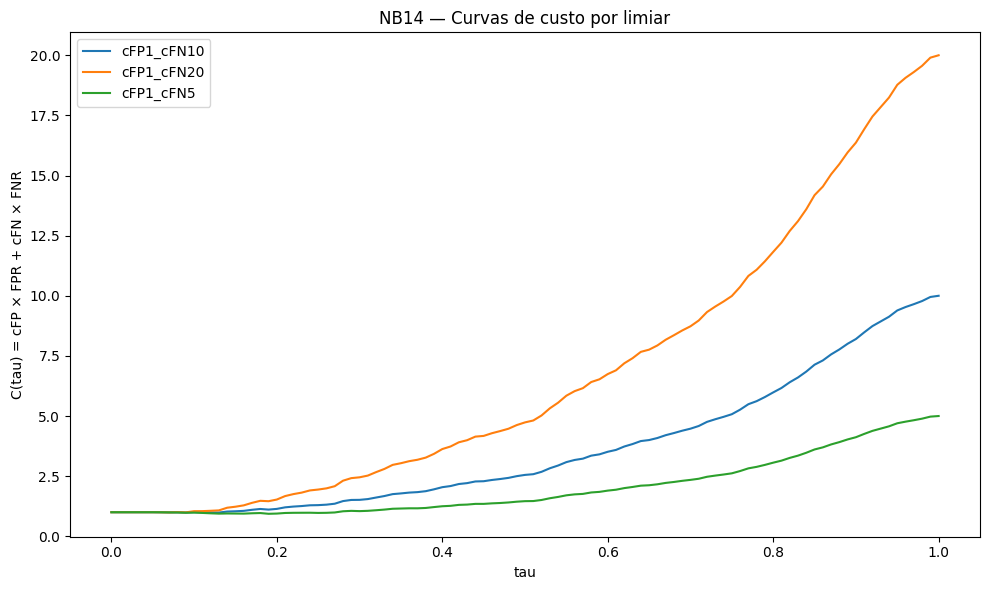

[2026-07-23 23:14:35] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb14/14_fig01_cost_curves.png


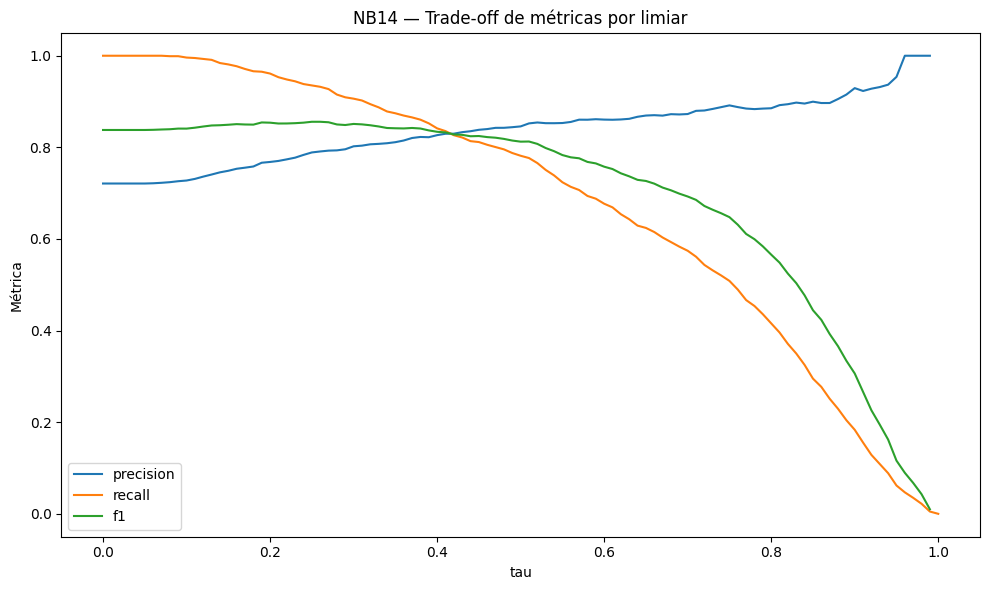

[2026-07-23 23:14:36] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb14/14_fig02_tau_metrics_tradeoff.png


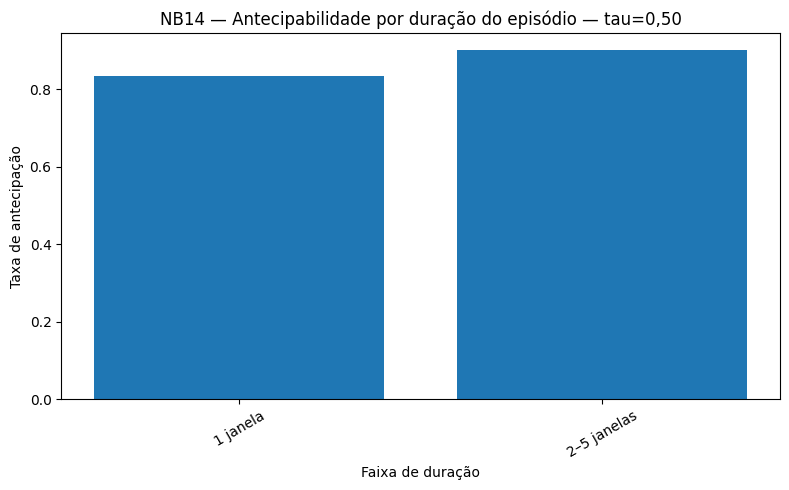

[2026-07-23 23:14:37] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb14/14_fig03_duration_anticipability.png


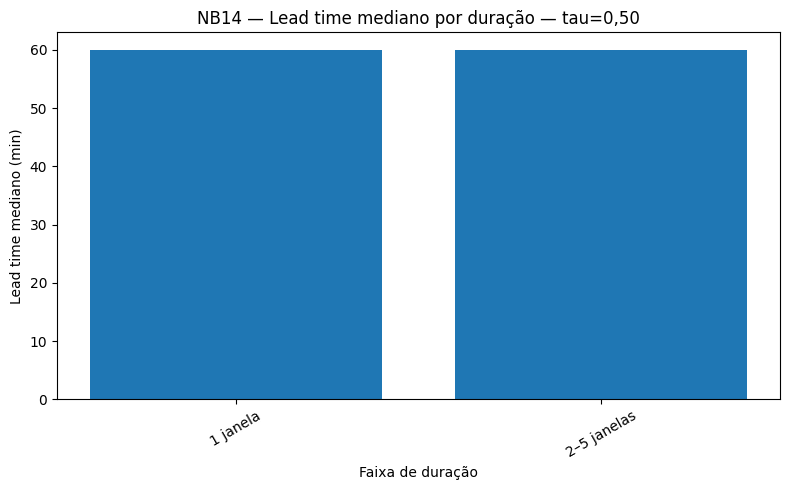

[2026-07-23 23:14:37] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb14/14_fig04_lead_time_by_duration.png


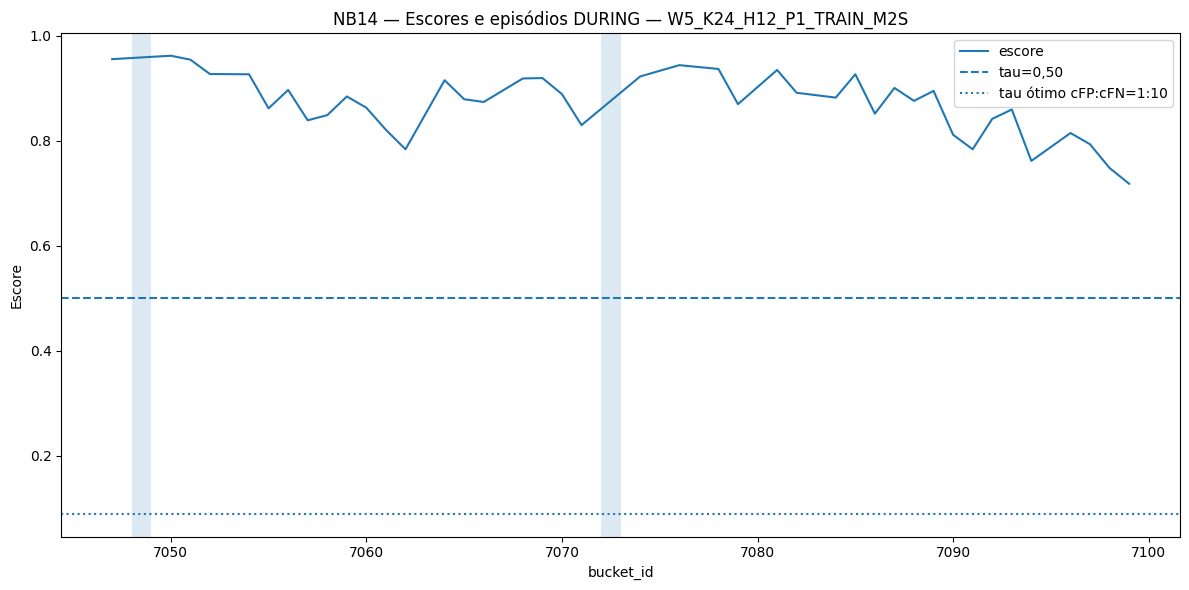

[2026-07-23 23:14:37] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb14/14_fig05_timeline_scores_main.png

NB14 concluído.

Artefatos gerados:


,artifact,path,exists
0,scores_selected,/content/drive/MyDrive/Mestrado/04-reports/14_...,True
1,threshold_metrics,/content/drive/MyDrive/Mestrado/04-reports/14_...,True
2,cost_curve,/content/drive/MyDrive/Mestrado/04-reports/14_...,True
3,optimal_tau,/content/drive/MyDrive/Mestrado/04-reports/14_...,True
4,false_alerts,/content/drive/MyDrive/Mestrado/04-reports/14_...,True
5,episode_anticipability_by_tau,/content/drive/MyDrive/Mestrado/04-reports/14_...,True
6,episode_anticipability,/content/drive/MyDrive/Mestrado/04-reports/14_...,True
7,episode_duration_summary,/content/drive/MyDrive/Mestrado/04-reports/14_...,True
8,scenario_summary,/content/drive/MyDrive/Mestrado/04-reports/14_...,True
9,summary_json,/content/drive/MyDrive/Mestrado/04-reports/14_...,True



Figuras geradas:


,figure,path,exists
0,cost_curve,/content/drive/MyDrive/Mestrado/04-reports/fig...,True
1,metrics_tradeoff,/content/drive/MyDrive/Mestrado/04-reports/fig...,True
2,duration_anticipability,/content/drive/MyDrive/Mestrado/04-reports/fig...,True
3,lead_time_by_duration,/content/drive/MyDrive/Mestrado/04-reports/fig...,True
4,timeline_scores,/content/drive/MyDrive/Mestrado/04-reports/fig...,True



Taus ótimos por razão de custo:


,scenario_label,tau,cost_label,c_fp,c_fn,cost,cost_normalized,fpr,fnr,precision,recall,f1,false_alerts_per_day,score_source,model,feature_set,optimality_rule
0,W5_K24_H12_P1_TRAIN_M2S,0.09,cFP1_cFN10,1.0,10.0,0.984197,0.089472,0.974227,0.000997,0.726087,0.999003,0.840957,78.263120,NB11_calibrated,logistic_regression,temporal_core,minimize_cFP_FPR_plus_cFN_FNR_then_low_FNR_low...
1,W5_K24_H12_P1_TRAIN_M2S,0.07,cFP1_cFN20,1.0,20.0,0.992268,0.047251,0.992268,0.000000,0.722622,1.000000,0.838980,79.712437,NB11_calibrated,logistic_regression,temporal_core,minimize_cFP_FPR_plus_cFN_FNR_then_low_FNR_low...
2,W5_K24_H12_P1_TRAIN_M2S,0.19,cFP1_cFN5,1.0,5.0,0.934786,0.155798,0.760309,0.034895,0.766429,0.965105,0.854369,61.078361,NB11_calibrated,logistic_regression,temporal_core,minimize_cFP_FPR_plus_cFN_FNR_then_low_FNR_low...
3,W5_K24_H12_P1_TRAIN_P95,0.15,cFP1_cFN10,1.0,10.0,0.996656,0.090605,0.996656,0.000000,0.782957,1.000000,0.878268,62.462882,NB12_sensitivity_fixed,logistic_regression,temporal_core,minimize_cFP_FPR_plus_cFN_FNR_then_low_FNR_low...
4,W5_K24_H12_P1_TRAIN_P95,0.15,cFP1_cFN20,1.0,20.0,0.996656,0.047460,0.996656,0.000000,0.782957,1.000000,0.878268,62.462882,NB12_sensitivity_fixed,logistic_regression,temporal_core,minimize_cFP_FPR_plus_cFN_FNR_then_low_FNR_low...
5,W5_K24_H12_P1_TRAIN_P95,0.26,cFP1_cFN5,1.0,5.0,0.955324,0.159221,0.876254,0.015814,0.801515,0.984186,0.883507,54.917031,NB12_sensitivity_fixed,logistic_regression,temporal_core,minimize_cFP_FPR_plus_cFN_FNR_then_low_FNR_low...



Sumário por cenário:


,scenario_label,is_main_scenario,is_p95_sensitivity,score_source,score_source_file,model,feature_set,n_scored_rows,n_total_episodes,duration_one_window_pct,tau_reference,precision_tau_reference,recall_tau_reference,f1_tau_reference,fpr_tau_reference,fnr_tau_reference,false_alerts_per_day_tau_reference,n_evaluable_episodes_tau_reference,n_anticipated_episodes_tau_reference,episode_anticipation_rate_tau_reference,lead_time_minutes_mean_tau_reference,lead_time_minutes_median_tau_reference,tau_opt_cFP1_cFN10,cost_opt_cFP1_cFN10,recall_at_opt_cFP1_cFN10,fpr_at_opt_cFP1_cFN10,fnr_at_opt_cFP1_cFN10,tau_opt_cFP1_cFN20,cost_opt_cFP1_cFN20,recall_at_opt_cFP1_cFN20,fpr_at_opt_cFP1_cFN20,fnr_at_opt_cFP1_cFN20,tau_opt_cFP1_cFN5,cost_opt_cFP1_cFN5,recall_at_opt_cFP1_cFN5,fpr_at_opt_cFP1_cFN5,fnr_at_opt_cFP1_cFN5
0,W5_K24_H12_P1_TRAIN_M2S,1,0,NB11_calibrated,/content/drive/MyDrive/Mestrado/04-reports/11_...,logistic_regression,temporal_core,1391,388,0.773196,0.5,0.845739,0.781655,0.812435,0.368557,0.218345,29.607477,34,29,0.852941,53.62069,60.0,0.09,0.984197,0.999003,0.974227,0.000997,0.07,0.992268,1.0,0.992268,0.0,0.19,0.934786,0.965105,0.760309,0.034895
1,W5_K24_H12_P1_TRAIN_P95,0,1,NB12_sensitivity_fixed,/content/drive/MyDrive/Mestrado/04-reports/12_...,logistic_regression,temporal_core,1374,471,0.762208,0.5,0.844203,0.866977,0.855438,0.575251,0.133023,36.052402,35,32,0.914286,52.34375,60.0,0.15,0.996656,1.000000,0.996656,0.000000,0.15,0.996656,1.0,0.996656,0.0,0.26,0.955324,0.984186,0.876254,0.015814



Todos os outputs declarados foram gerados.

Leitura preliminar: o NB14 gerou os insumos para transformar os escores em análise operacional de antecipabilidade e política de limiar tau. O EWMA causal do NB11 foi registrado apenas como baseline temporal comparativo, sem compor C(tau) no protocolo adotado. A Conclusão da Etapa deve ser redigida depois da inspeção dos artefatos, continuando a numeração do Markdown inicial.


In [ ]:
# ============================================================
# NB14 — Episódios, Antecipabilidade e Função de Custo C(tau)
# Pipeline PPCOMP/DM — Dissertação de Mestrado
#
# Célula única:
# - consome episódios e estados do NB10;
# - consome escores preferencialmente do NB11;
# - registra o EWMA causal do NB11 como baseline temporal comparativo,
#   sem usá-lo como política principal de C(tau);
# - usa NB13 apenas se ele tiver superado o NB11 pelo critério definido;
# - avalia antecipabilidade por episódio e por faixa de duração;
# - varre tau em [0,1] para diferentes razões cFP:cFN;
# - materializa artefatos primários da etapa em 04-reports/;
# - salva figuras apenas em 04-reports/figures_nb14/.
# ============================================================

import os
import re
import json
import math
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    display = print

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)

# ============================================================
# 0. Configuração geral
# ============================================================

RUN_TIMESTAMP = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
RUN_TIMESTAMP_FILE = datetime.now().strftime("%Y%m%d_%H%M%S")

def now_str():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")

def log(msg):
    print(f"[{now_str()}] {msg}", flush=True)

def ensure_dir(path):
    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)
    return path

def read_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def save_json(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2, default=str)

IN_COLAB = "google.colab" in str(get_ipython()) if "get_ipython" in globals() else False
if IN_COLAB:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
    except Exception as exc:
        log(f"[AVISO] Não foi possível montar o Google Drive automaticamente: {exc}")

BASE_DIR = (
    Path("/content/drive/MyDrive/Mestrado")
    if Path("/content/drive/MyDrive/Mestrado").exists()
    else Path.cwd()
)

DATA_DIR = BASE_DIR / "02-datasets"
FEATURES_DIR = DATA_DIR / "03-features"
MODELS_DIR = BASE_DIR / "03-models"
REPORTS_DIR = ensure_dir(BASE_DIR / "04-reports")
FIGURES_DIR = ensure_dir(REPORTS_DIR / "figures_nb14")

CONFIG = {
    "main_scenario_default": "W5_K24_H12_P1_TRAIN_M2S",
    "include_p95_if_scores_exist": True,
    "p95_scenario_default": "W5_K24_H12_P1_TRAIN_P95",
    "tau_step": 0.01,
    "classification_reference_tau": 0.50,
    "cost_ratios": [
        {"cost_label": "cFP1_cFN5", "c_fp": 1.0, "c_fn": 5.0},
        {"cost_label": "cFP1_cFN10", "c_fp": 1.0, "c_fn": 10.0},
        {"cost_label": "cFP1_cFN20", "c_fp": 1.0, "c_fn": 20.0},
    ],
    "low_count_threshold_duration_bin": 5,
    "prefer_fixed_protocol_scores": True,
    "use_nb13_only_if_decision_allows": True,
    "min_delta_f1_lstm_to_replace_nb11": 0.03,
    "save_conclusion_notes_txt": True,
    "ewma_baseline_note": (
        "O EWMA causal foi incorporado no NB11 como baseline temporal suavizado e "
        "comparativo. No NB14 ele não é usado como escore principal nem como política "
        "de limiar em C(tau), pois isso exigiria uma série operacional própria "
        "score_ewma ou alert_ewma e abriria uma ramificação metodológica adicional."
    ),
}

TAU_GRID = np.round(
    np.arange(0.0, 1.0 + CONFIG["tau_step"] / 2, CONFIG["tau_step"]),
    4
)

OUTPUT_FILES = {
    "scores_selected": REPORTS_DIR / "14_scores_selected.parquet",
    "threshold_metrics": REPORTS_DIR / "14_threshold_metrics_by_tau.csv",
    "cost_curve": REPORTS_DIR / "14_cost_curve.csv",
    "optimal_tau": REPORTS_DIR / "14_optimal_tau_by_cost.csv",
    "false_alerts": REPORTS_DIR / "14_false_alerts_by_tau.csv",
    "episode_anticipability_by_tau": REPORTS_DIR / "14_episode_anticipability_by_tau.csv",
    "episode_anticipability": REPORTS_DIR / "14_episode_anticipability.csv",
    "episode_duration_summary": REPORTS_DIR / "14_episode_duration_summary.csv",
    "scenario_summary": REPORTS_DIR / "14_scenario_summary.csv",
    "summary_json": REPORTS_DIR / "14_nb14_summary.json",
    "conclusion_notes": REPORTS_DIR / "14_conclusion_notes.txt",
}

FIGURE_FILES = {
    "cost_curve": FIGURES_DIR / "14_fig01_cost_curves.png",
    "metrics_tradeoff": FIGURES_DIR / "14_fig02_tau_metrics_tradeoff.png",
    "duration_anticipability": FIGURES_DIR / "14_fig03_duration_anticipability.png",
    "lead_time_by_duration": FIGURES_DIR / "14_fig04_lead_time_by_duration.png",
    "timeline_scores": FIGURES_DIR / "14_fig05_timeline_scores_main.png",
}

log("=" * 100)
log("NB14 — Episódios, Antecipabilidade e Função de Custo C(tau)")
log(f"RUN_TIMESTAMP = {RUN_TIMESTAMP}")
log(f"BASE_DIR = {BASE_DIR}")
log(f"REPORTS_DIR = {REPORTS_DIR}")
log(f"FIGURES_DIR = {FIGURES_DIR}")
log("=" * 100)

# ============================================================
# 1. Localização de artefatos
# ============================================================

def find_file(filename, search_roots=None, required=True):
    if search_roots is None:
        search_roots = [
            REPORTS_DIR,
            REPORTS_DIR / "nb10",
            REPORTS_DIR / "nb11",
            REPORTS_DIR / "nb12",
            REPORTS_DIR / "nb13",
            BASE_DIR,
        ]

    direct_candidates = [Path(root) / filename for root in search_roots]
    for p in direct_candidates:
        if p.exists():
            return p

    for root in search_roots:
        root = Path(root)
        if root.exists():
            matches = sorted(
                root.rglob(filename),
                key=lambda x: x.stat().st_mtime,
                reverse=True
            )
            if matches:
                return matches[0]

    if required:
        msg = "Arquivo obrigatório não encontrado: " + filename + "\nCandidatos diretos:\n"
        msg += "\n".join(str(p) for p in direct_candidates)
        raise FileNotFoundError(msg)
    return None

# Entradas NB10
PATH_EPISODES = find_file("10_scenario_episodes.parquet", required=True)
PATH_STATES = find_file("10_scenario_series_states.parquet", required=True)
PATH_DECISIONS = find_file("10_scenario_decisions.csv", required=False)

# Entradas NB11
PATH_WINNER = find_file("11_winner_model.json", required=True)
PATH_NB11_SUMMARY = find_file("11_nb11_summary.json", required=False)
PATH_NB11_CALIBRATION = find_file("11_calibration_summary.csv", required=False)
PATH_NB11_SCORES_CAL = find_file("11_scores_calibrated.parquet", required=False)
PATH_NB11_SCORES_RAW = find_file("11_scores_raw.parquet", required=False)

# Entradas NB12, opcionais para sensibilidade p95
PATH_NB12_SCORES = find_file("12_scores_sensitivity_fixed.parquet", required=False)
PATH_NB12_REVIEW = find_file("12_train_p95_review.json", required=False)
PATH_NB12_SUMMARY = find_file("12_nb12_summary.json", required=False)

# Entradas NB13, opcionais e condicionais
PATH_NB13_SUMMARY = find_file("13_lstm_summary.json", required=False)
PATH_NB13_SCORES = find_file("13_lstm_scores.parquet", required=False)

log("Artefatos localizados:")
for name, path in {
    "10_scenario_episodes": PATH_EPISODES,
    "10_scenario_series_states": PATH_STATES,
    "10_scenario_decisions": PATH_DECISIONS,
    "11_winner_model": PATH_WINNER,
    "11_nb11_summary": PATH_NB11_SUMMARY,
    "11_calibration_summary": PATH_NB11_CALIBRATION,
    "11_scores_calibrated": PATH_NB11_SCORES_CAL,
    "11_scores_raw": PATH_NB11_SCORES_RAW,
    "12_scores_sensitivity_fixed": PATH_NB12_SCORES,
    "13_lstm_summary": PATH_NB13_SUMMARY,
    "13_lstm_scores": PATH_NB13_SCORES,
}.items():
    log(f"{name}: {path}")

# ============================================================
# 2. Funções de inferência de colunas e parsing
# ============================================================

def infer_column(df, candidates, required=True, label="coluna"):
    cols = list(df.columns)
    lower_map = {str(c).lower(): c for c in cols}

    for c in candidates:
        if c in df.columns:
            return c
        if str(c).lower() in lower_map:
            return lower_map[str(c).lower()]

    if required:
        raise ValueError(
            f"Não foi possível inferir {label}. "
            f"Candidatos: {candidates}. Colunas disponíveis: {cols}"
        )
    return None

def parse_scenario_label(label):
    label = str(label)
    m = re.match(
        r"W(?P<W>\d+)_K(?P<K>\d+)_H(?P<H>\d+)_P(?P<P>\d+)_(?P<threshold>.+)",
        label
    )
    if not m:
        return {
            "scenario_label": label,
            "window_minutes": np.nan,
            "k_windows": np.nan,
            "h_windows": np.nan,
            "persistence_min_windows": np.nan,
            "threshold_family": "unknown",
        }

    d = m.groupdict()
    return {
        "scenario_label": label,
        "window_minutes": int(d["W"]),
        "k_windows": int(d["K"]),
        "h_windows": int(d["H"]),
        "persistence_min_windows": int(d["P"]),
        "threshold_family": str(d["threshold"]).lower(),
    }

def get_window_minutes(label, fallback=5):
    try:
        return int(parse_scenario_label(label)["window_minutes"])
    except Exception:
        return int(fallback)

def get_h_windows(label, fallback=12):
    try:
        return int(parse_scenario_label(label)["h_windows"])
    except Exception:
        return int(fallback)

def duration_bucket_from_windows(duration_windows):
    if pd.isna(duration_windows):
        return "unknown"
    d = int(duration_windows)
    if d <= 1:
        return "1 janela"
    if 2 <= d <= 5:
        return "2–5 janelas"
    if 6 <= d <= 20:
        return "6–20 janelas"
    return ">20 janelas"

def duration_bucket_order(bucket):
    order = {
        "1 janela": 1,
        "2–5 janelas": 2,
        "6–20 janelas": 3,
        ">20 janelas": 4,
        "unknown": 99,
    }
    return order.get(str(bucket), 99)

def safe_div(num, den):
    den = float(den)
    if den == 0 or pd.isna(den):
        return np.nan
    return float(num) / den

def boolish_contains(value, patterns):
    s = str(value).lower()
    return any(p.lower() in s for p in patterns)

# ============================================================
# 3. Carregamento de metadados dos notebooks anteriores
# ============================================================

winner = read_json(PATH_WINNER)
nb11_summary = read_json(PATH_NB11_SUMMARY) if PATH_NB11_SUMMARY else {}
nb12_review = read_json(PATH_NB12_REVIEW) if PATH_NB12_REVIEW else {}
nb12_summary = read_json(PATH_NB12_SUMMARY) if PATH_NB12_SUMMARY else {}
nb13_summary = read_json(PATH_NB13_SUMMARY) if PATH_NB13_SUMMARY else {}

winner_from_summary = nb11_summary.get("winner", {}) if isinstance(nb11_summary, dict) else {}
MAIN_SCENARIO = (
    winner.get("scenario_label")
    or winner_from_summary.get("scenario_label")
    or CONFIG["main_scenario_default"]
)
P95_SCENARIO = (
    CONFIG["p95_scenario_default"]
    if "TRAIN_M2S" not in MAIN_SCENARIO
    else MAIN_SCENARIO.replace("TRAIN_M2S", "TRAIN_P95")
)

WINNER_MODEL = winner.get("model", winner_from_summary.get("model", "unknown"))
WINNER_FEATURE_SET = winner.get("feature_set", winner_from_summary.get("feature_set", "unknown"))
WINNER_F1_TSCV = winner.get("f1_tscv_mean", winner_from_summary.get("f1_tscv_mean", np.nan))

log("Referência metodológica herdada:")
log(f"MAIN_SCENARIO = {MAIN_SCENARIO}")
log(f"P95_SCENARIO  = {P95_SCENARIO}")
log(f"WINNER_MODEL = {WINNER_MODEL}")
log(f"WINNER_FEATURE_SET = {WINNER_FEATURE_SET}")
log(f"WINNER_F1_TSCV = {WINNER_F1_TSCV}")

# ============================================================
# 4. Decisão condicional sobre fonte de escores
# ============================================================

def extract_nested_values(obj):
    values = []
    if isinstance(obj, dict):
        for v in obj.values():
            values.extend(extract_nested_values(v))
    elif isinstance(obj, list):
        for v in obj:
            values.extend(extract_nested_values(v))
    else:
        values.append(obj)
    return values

def nb13_allows_replacement(summary):
    if not summary:
        return False, "13_lstm_summary.json ausente."

    all_values = [str(v).lower() for v in extract_nested_values(summary)]
    joined = " | ".join(all_values)

    if "keep_nb11_scores_for_nb14" in joined:
        return False, "NB13 registrou keep_nb11_scores_for_nb14."
    if "use_lstm_scores_for_nb14" in joined or "replace_nb11_scores_for_nb14" in joined:
        return True, "NB13 registrou uso dos escores LSTM para o NB14."

    delta_candidates = []
    for key in [
        "delta_f1_vs_nb11",
        "delta_vs_nb11",
        "f1_delta_vs_nb11",
        "best_delta_f1",
    ]:
        if key in summary:
            delta_candidates.append(summary.get(key))

    for section_key in ["comparison_with_nb11", "decision", "winner", "best_lstm"]:
        section = summary.get(section_key) if isinstance(summary, dict) else None
        if isinstance(section, dict):
            for key in [
                "delta_f1_vs_nb11",
                "delta_vs_nb11",
                "f1_delta_vs_nb11",
                "best_delta_f1",
            ]:
                if key in section:
                    delta_candidates.append(section.get(key))

    for delta in delta_candidates:
        try:
            if float(delta) >= CONFIG["min_delta_f1_lstm_to_replace_nb11"]:
                return True, f"Delta F1 LSTM vs NB11 = {float(delta):.4f}."
        except Exception:
            pass

    return False, "NB13 não apresentou evidência estruturada para substituir NB11."

USE_NB13, NB13_DECISION_REASON = nb13_allows_replacement(nb13_summary)

if CONFIG["use_nb13_only_if_decision_allows"] and USE_NB13 and PATH_NB13_SCORES:
    PRIMARY_SCORE_SOURCE = "NB13_LSTM"
    PRIMARY_SCORE_PATH = PATH_NB13_SCORES
elif PATH_NB11_SCORES_CAL:
    PRIMARY_SCORE_SOURCE = "NB11_calibrated"
    PRIMARY_SCORE_PATH = PATH_NB11_SCORES_CAL
elif PATH_NB11_SCORES_RAW:
    PRIMARY_SCORE_SOURCE = "NB11_raw"
    PRIMARY_SCORE_PATH = PATH_NB11_SCORES_RAW
else:
    raise FileNotFoundError(
        "Nenhum arquivo de escore disponível. Esperado 11_scores_calibrated.parquet "
        "ou 11_scores_raw.parquet; 13_lstm_scores.parquet só é aceito se NB13 superar NB11."
    )

log("Fonte primária de escores:")
log(f"PRIMARY_SCORE_SOURCE = {PRIMARY_SCORE_SOURCE}")
log(f"PRIMARY_SCORE_PATH = {PRIMARY_SCORE_PATH}")
log(f"NB13_DECISION_REASON = {NB13_DECISION_REASON}")

EWMA_BASELINE_NOTE = CONFIG["ewma_baseline_note"]
log("Nota metodológica sobre EWMA causal do NB11:")
log(EWMA_BASELINE_NOTE)

# ============================================================
# 5. Padronização dos escores
# ============================================================

def standardize_score_frame(df, source_name, source_path):
    df = df.copy()
    df = df.loc[:, ~df.columns.duplicated()].copy()

    scenario_col = infer_column(
        df,
        ["scenario_label", "scenario", "scenario_id", "config_label"],
        label="coluna de cenário nos escores",
    )

    time_col = infer_column(
        df,
        ["bucket_id", "time_order", "bucket", "row_end_bucket_id", "row_end_position"],
        label="coluna temporal nos escores",
    )

    y_col = infer_column(
        df,
        ["y_true", "y", "y_nb11", "y_nb12", "target", "label"],
        label="coluna alvo nos escores",
    )

    score_col = infer_column(
        df,
        [
            "score_calibrated",
            "y_score_calibrated",
            "calibrated_score",
            "score_platt",
            "score_isotonic",
            "score_raw",
            "y_score",
            "score",
            "probability",
            "proba",
            "score_lstm",
        ],
        label="coluna de escore",
    )

    protocol_col = infer_column(
        df,
        ["protocol", "validation", "split", "validation_protocol"],
        required=False,
        label="coluna de protocolo",
    )

    if CONFIG["prefer_fixed_protocol_scores"] and protocol_col:
        fixed_mask = df[protocol_col].astype(str).str.lower().str.contains("fixed|80_20|80/20", regex=True, na=False)
        if fixed_mask.sum() > 0:
            df = df[fixed_mask].copy()

    model_col = infer_column(df, ["model", "model_name", "estimator"], required=False, label="modelo")
    feature_set_col = infer_column(df, ["feature_set", "featureset"], required=False, label="feature set")
    fold_col = infer_column(df, ["fold"], required=False, label="fold")
    seed_col = infer_column(df, ["seed"], required=False, label="seed")
    window_col = infer_column(df, ["window_minutes", "W"], required=False, label="window_minutes")
    h_col = infer_column(df, ["h_windows", "H", "horizon_h"], required=False, label="h_windows")

    out = pd.DataFrame({
        "scenario_label": df[scenario_col].astype(str),
        "bucket_id": pd.to_numeric(df[time_col], errors="coerce"),
        "y_true": pd.to_numeric(df[y_col], errors="coerce"),
        "score": pd.to_numeric(df[score_col], errors="coerce"),
    })

    out["score_source"] = source_name
    out["score_source_file"] = str(source_path)
    out["original_score_column"] = score_col
    out["protocol"] = df[protocol_col].astype(str).values if protocol_col else "unknown"
    out["model"] = df[model_col].astype(str).values if model_col else WINNER_MODEL
    out["feature_set"] = df[feature_set_col].astype(str).values if feature_set_col else WINNER_FEATURE_SET
    out["fold"] = df[fold_col].values if fold_col else np.nan
    out["seed"] = df[seed_col].values if seed_col else np.nan

    if window_col:
        out["window_minutes"] = pd.to_numeric(df[window_col], errors="coerce").values
    else:
        out["window_minutes"] = out["scenario_label"].map(lambda s: get_window_minutes(s, fallback=5))

    if h_col:
        out["h_windows"] = pd.to_numeric(df[h_col], errors="coerce").values
    else:
        out["h_windows"] = out["scenario_label"].map(lambda s: get_h_windows(s, fallback=12))

    out = out.replace([np.inf, -np.inf], np.nan)
    out = out.dropna(subset=["scenario_label", "bucket_id", "y_true", "score"])
    out["bucket_id"] = out["bucket_id"].astype(int)
    out["y_true"] = out["y_true"].astype(int)
    out["score"] = out["score"].clip(0.0, 1.0)

    # Se houver múltiplas sementes/folds/configurações para o mesmo bucket,
    # usa média dos escores e conserva y_true máximo como defesa.
    group_cols = ["scenario_label", "bucket_id"]
    agg = {
        "y_true": "max",
        "score": "mean",
        "score_source": "first",
        "score_source_file": "first",
        "original_score_column": "first",
        "protocol": lambda x: "|".join(sorted(set(map(str, x))))[:200],
        "model": lambda x: "|".join(sorted(set(map(str, x))))[:200],
        "feature_set": lambda x: "|".join(sorted(set(map(str, x))))[:200],
        "window_minutes": "first",
        "h_windows": "first",
    }
    out = out.groupby(group_cols, as_index=False).agg(agg)
    out["window_minutes"] = out["window_minutes"].fillna(out["scenario_label"].map(lambda s: get_window_minutes(s, 5))).astype(int)
    out["h_windows"] = out["h_windows"].fillna(out["scenario_label"].map(lambda s: get_h_windows(s, 12))).astype(int)

    parsed = out["scenario_label"].apply(parse_scenario_label).apply(pd.Series)
    for c in parsed.columns:
        if c not in out.columns:
            out[c] = parsed[c]

    return out.sort_values(["scenario_label", "bucket_id"]).reset_index(drop=True)

df_primary_scores_raw = pd.read_parquet(PRIMARY_SCORE_PATH)
df_scores_primary = standardize_score_frame(
    df_primary_scores_raw,
    source_name=PRIMARY_SCORE_SOURCE,
    source_path=PRIMARY_SCORE_PATH
)

score_frames = [df_scores_primary]

# Inclui, quando existir, a sensibilidade p95 do NB12 sem deslocar o cenário principal.
if CONFIG["include_p95_if_scores_exist"] and PATH_NB12_SCORES:
    try:
        df_nb12_scores_raw = pd.read_parquet(PATH_NB12_SCORES)
        df_scores_nb12 = standardize_score_frame(
            df_nb12_scores_raw,
            source_name="NB12_sensitivity_fixed",
            source_path=PATH_NB12_SCORES
        )
        score_frames.append(df_scores_nb12)
        log("Escores de sensibilidade do NB12 incluídos para comparação, quando aplicável.")
    except Exception as exc:
        log(f"[AVISO] Não foi possível padronizar escores do NB12: {exc}")

df_scores = pd.concat(score_frames, ignore_index=True)
df_scores = df_scores.drop_duplicates(
    subset=["scenario_label", "bucket_id", "score_source"],
    keep="first"
).copy()

available_score_scenarios = sorted(df_scores["scenario_label"].dropna().unique().tolist())
RUN_SCENARIOS = [s for s in [MAIN_SCENARIO, P95_SCENARIO] if s in available_score_scenarios]

if MAIN_SCENARIO not in RUN_SCENARIOS:
    log("[AVISO] Cenário principal não encontrado nos escores padronizados.")
    if available_score_scenarios:
        RUN_SCENARIOS = [available_score_scenarios[0]]
        log(f"[AVISO] Usando primeiro cenário disponível como fallback: {RUN_SCENARIOS[0]}")
    else:
        raise ValueError("Nenhum cenário disponível nos escores.")

df_scores = df_scores[df_scores["scenario_label"].isin(RUN_SCENARIOS)].copy()
df_scores.to_parquet(OUTPUT_FILES["scores_selected"], index=False)

log("Cenários avaliados no NB14:")
print(RUN_SCENARIOS)
log(f"df_scores padronizado: {df_scores.shape}")
display(df_scores.head())

# ============================================================
# 6. Padronização de episódios e estados
# ============================================================

df_episodes_raw = pd.read_parquet(PATH_EPISODES)
df_states_raw = pd.read_parquet(PATH_STATES)

scenario_col_ep = infer_column(
    df_episodes_raw,
    ["scenario_label", "scenario", "scenario_id", "config_label"],
    label="cenário em episódios",
)
start_col_ep = infer_column(
    df_episodes_raw,
    ["episode_start_bucket_id", "start_bucket_id", "start_bucket", "bucket_start", "start"],
    label="início do episódio",
)
end_col_ep = infer_column(
    df_episodes_raw,
    ["episode_end_bucket_id", "end_bucket_id", "end_bucket", "bucket_end", "end"],
    label="fim do episódio",
)

duration_col_ep = infer_column(
    df_episodes_raw,
    ["duration_windows", "episode_duration_windows", "n_windows", "length_windows"],
    required=False,
    label="duração em janelas",
)

def standardize_episodes(df):
    out = pd.DataFrame({
        "scenario_label": df[scenario_col_ep].astype(str),
        "episode_start_bucket_id": pd.to_numeric(df[start_col_ep], errors="coerce"),
        "episode_end_bucket_id": pd.to_numeric(df[end_col_ep], errors="coerce"),
    })
    out = out.dropna(subset=["episode_start_bucket_id", "episode_end_bucket_id"])
    out["episode_start_bucket_id"] = out["episode_start_bucket_id"].astype(int)
    out["episode_end_bucket_id"] = out["episode_end_bucket_id"].astype(int)

    if duration_col_ep:
        out["duration_windows"] = pd.to_numeric(df[duration_col_ep], errors="coerce").values
    else:
        out["duration_windows"] = out["episode_end_bucket_id"] - out["episode_start_bucket_id"] + 1

    out["duration_windows"] = out["duration_windows"].fillna(
        out["episode_end_bucket_id"] - out["episode_start_bucket_id"] + 1
    ).astype(int)

    parsed = out["scenario_label"].apply(parse_scenario_label).apply(pd.Series)
    for c in parsed.columns:
        if c not in out.columns:
            out[c] = parsed[c]

    out["window_minutes"] = out["window_minutes"].fillna(
        out["scenario_label"].map(lambda s: get_window_minutes(s, 5))
    ).astype(int)
    out["h_windows"] = out["h_windows"].fillna(
        out["scenario_label"].map(lambda s: get_h_windows(s, 12))
    ).astype(int)
    out["duration_minutes"] = out["duration_windows"] * out["window_minutes"]
    out["duration_bucket"] = out["duration_windows"].map(duration_bucket_from_windows)
    out["duration_bucket_order"] = out["duration_bucket"].map(duration_bucket_order)

    return out.sort_values(
        ["scenario_label", "episode_start_bucket_id", "episode_end_bucket_id"]
    ).reset_index(drop=True)

df_episodes = standardize_episodes(df_episodes_raw)
df_episodes = df_episodes[df_episodes["scenario_label"].isin(RUN_SCENARIOS)].copy()

scenario_col_states = infer_column(
    df_states_raw,
    ["scenario_label", "scenario", "scenario_id", "config_label"],
    label="cenário em estados",
)
state_col = infer_column(
    df_states_raw,
    ["state", "operational_state", "estado", "S"],
    required=False,
    label="estado operacional",
)
bucket_col_states = infer_column(
    df_states_raw,
    ["bucket_id", "bucket", "time_order"],
    label="bucket_id em estados",
)

df_states = df_states_raw[
    df_states_raw[scenario_col_states].astype(str).isin(RUN_SCENARIOS)
].copy()
df_states["scenario_label"] = df_states[scenario_col_states].astype(str)
df_states["bucket_id"] = pd.to_numeric(df_states[bucket_col_states], errors="coerce")
df_states = df_states.dropna(subset=["bucket_id"])
df_states["bucket_id"] = df_states["bucket_id"].astype(int)
if state_col:
    df_states["state_nb10"] = df_states[state_col].astype(str)
else:
    df_states["state_nb10"] = "unknown"

log(f"df_episodes padronizado: {df_episodes.shape}")
log(f"df_states padronizado: {df_states.shape}")
display(df_episodes.head())

# ============================================================
# 7. Métricas por tau e função de custo
# ============================================================

def confusion_counts(y_true, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    return tn, fp, fn, tp

def metrics_at_tau(scores_df, tau):
    y_true = scores_df["y_true"].astype(int).to_numpy()
    score = scores_df["score"].astype(float).to_numpy()
    y_pred = (score >= float(tau)).astype(int)

    tn, fp, fn, tp = confusion_counts(y_true, y_pred)
    n = len(y_true)
    positive_rate = safe_div(y_true.sum(), n)
    alert_rate = safe_div(y_pred.sum(), n)

    precision = safe_div(tp, tp + fp)
    recall = safe_div(tp, tp + fn)
    specificity = safe_div(tn, tn + fp)
    f1 = safe_div(2 * precision * recall, precision + recall) if not (pd.isna(precision) or pd.isna(recall)) else np.nan
    fpr = safe_div(fp, fp + tn)
    fnr = safe_div(fn, fn + tp)

    window_minutes = int(scores_df["window_minutes"].dropna().iloc[0]) if "window_minutes" in scores_df.columns and scores_df["window_minutes"].notna().any() else 5
    total_days = (n * window_minutes) / (60 * 24)

    return {
        "tau": float(tau),
        "n": int(n),
        "positive_rate": positive_rate,
        "alert_rate": alert_rate,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "accuracy": safe_div(tp + tn, n),
        "precision": precision,
        "recall": recall,
        "specificity": specificity,
        "f1": f1,
        "fpr": fpr,
        "fnr": fnr,
        "false_alerts": int(fp),
        "false_alerts_per_day": safe_div(fp, total_days),
        "window_minutes": int(window_minutes),
        "total_scored_days": float(total_days),
    }

threshold_rows = []
for scenario_label in RUN_SCENARIOS:
    s = df_scores[df_scores["scenario_label"] == scenario_label].copy()
    if s.empty:
        continue
    meta = parse_scenario_label(scenario_label)
    for tau in TAU_GRID:
        row = metrics_at_tau(s, tau)
        row.update({
            "scenario_label": scenario_label,
            "score_source": s["score_source"].iloc[0],
            "score_source_file": s["score_source_file"].iloc[0],
            "model": s["model"].iloc[0],
            "feature_set": s["feature_set"].iloc[0],
            **meta,
        })
        threshold_rows.append(row)

df_threshold_metrics = pd.DataFrame(threshold_rows)
df_threshold_metrics.to_csv(OUTPUT_FILES["threshold_metrics"], index=False)

cost_rows = []
for _, row in df_threshold_metrics.iterrows():
    for cr in CONFIG["cost_ratios"]:
        cost = cr["c_fp"] * row["fpr"] + cr["c_fn"] * row["fnr"]
        cost_norm = safe_div(cost, cr["c_fp"] + cr["c_fn"])
        cost_rows.append({
            "scenario_label": row["scenario_label"],
            "tau": row["tau"],
            "cost_label": cr["cost_label"],
            "c_fp": cr["c_fp"],
            "c_fn": cr["c_fn"],
            "cost": cost,
            "cost_normalized": cost_norm,
            "fpr": row["fpr"],
            "fnr": row["fnr"],
            "precision": row["precision"],
            "recall": row["recall"],
            "f1": row["f1"],
            "false_alerts_per_day": row["false_alerts_per_day"],
            "score_source": row["score_source"],
            "model": row["model"],
            "feature_set": row["feature_set"],
        })

df_cost_curve = pd.DataFrame(cost_rows)
df_cost_curve.to_csv(OUTPUT_FILES["cost_curve"], index=False)

optimal_rows = []
for (scenario_label, cost_label), grp in df_cost_curve.groupby(["scenario_label", "cost_label"]):
    opt = grp.sort_values(
        ["cost", "fnr", "fpr", "tau"],
        ascending=[True, True, True, True]
    ).iloc[0].to_dict()
    opt["optimality_rule"] = "minimize_cFP_FPR_plus_cFN_FNR_then_low_FNR_low_FPR_low_tau"
    optimal_rows.append(opt)

df_optimal_tau = pd.DataFrame(optimal_rows)
df_optimal_tau.to_csv(OUTPUT_FILES["optimal_tau"], index=False)

df_false_alerts = df_threshold_metrics[
    [
        "scenario_label",
        "tau",
        "false_alerts",
        "false_alerts_per_day",
        "alert_rate",
        "positive_rate",
        "fp",
        "tn",
        "fn",
        "tp",
        "score_source",
        "model",
        "feature_set",
    ]
].copy()
df_false_alerts.to_csv(OUTPUT_FILES["false_alerts"], index=False)

log("Métricas por tau e curvas de custo calculadas.")
display(df_optimal_tau.sort_values(["scenario_label", "cost_label"]))

# ============================================================
# 8. Antecipabilidade por episódio
# ============================================================

def compute_episode_detail_for_tau(episodes_s, scores_s, tau):
    scores_s = scores_s.sort_values("bucket_id").copy()
    score_lookup = dict(zip(scores_s["bucket_id"].astype(int), scores_s["score"].astype(float)))
    score_bucket_set = set(score_lookup.keys())

    rows = []
    for _, ep in episodes_s.iterrows():
        scenario_label = ep["scenario_label"]
        start = int(ep["episode_start_bucket_id"])
        end = int(ep["episode_end_bucket_id"])
        h_windows = int(ep.get("h_windows", get_h_windows(scenario_label, 12)))
        window_minutes = int(ep.get("window_minutes", get_window_minutes(scenario_label, 5)))

        previous_window = list(range(start - h_windows, start))
        available_previous = [b for b in previous_window if b in score_bucket_set]
        is_evaluable_full = len(available_previous) == h_windows
        is_evaluable_any = len(available_previous) > 0

        alert_buckets = [b for b in available_previous if score_lookup.get(b, -np.inf) >= float(tau)]
        if alert_buckets:
            first_alert_bucket = int(min(alert_buckets))
            lead_time_windows = int(start - first_alert_bucket)
            lead_time_minutes = int(lead_time_windows * window_minutes)
            anticipated_any = 1
            anticipated_full = int(is_evaluable_full)
        else:
            first_alert_bucket = np.nan
            lead_time_windows = np.nan
            lead_time_minutes = np.nan
            anticipated_any = 0
            anticipated_full = 0

        during_window = list(range(start, end + 1))
        available_during = [b for b in during_window if b in score_bucket_set]
        late_alert_buckets = [b for b in available_during if score_lookup.get(b, -np.inf) >= float(tau)]
        detected_during = int(len(late_alert_buckets) > 0)

        rows.append({
            "scenario_label": scenario_label,
            "tau": float(tau),
            "episode_start_bucket_id": start,
            "episode_end_bucket_id": end,
            "duration_windows": int(ep["duration_windows"]),
            "duration_minutes": int(ep["duration_minutes"]),
            "duration_bucket": ep["duration_bucket"],
            "duration_bucket_order": int(ep["duration_bucket_order"]),
            "window_minutes": window_minutes,
            "h_windows": h_windows,
            "available_previous_windows": int(len(available_previous)),
            "evaluable_full_horizon": int(is_evaluable_full),
            "evaluable_any_score": int(is_evaluable_any),
            "anticipated_full_horizon": int(anticipated_full),
            "anticipated_any_score": int(anticipated_any),
            "first_alert_bucket_id": first_alert_bucket,
            "lead_time_windows": lead_time_windows,
            "lead_time_minutes": lead_time_minutes,
            "detected_during": detected_during,
        })

    return pd.DataFrame(rows)

episode_tau_summary_rows = []
episode_detail_selected = []

for scenario_label in RUN_SCENARIOS:
    eps_s = df_episodes[df_episodes["scenario_label"] == scenario_label].copy()
    scores_s = df_scores[df_scores["scenario_label"] == scenario_label].copy()

    if eps_s.empty or scores_s.empty:
        continue

    # Sumário por todos os tau.
    for tau in TAU_GRID:
        detail = compute_episode_detail_for_tau(eps_s, scores_s, tau)
        total_episodes = len(detail)
        evaluable_full = int(detail["evaluable_full_horizon"].sum())
        anticipated_full = int(detail["anticipated_full_horizon"].sum())
        evaluable_any = int(detail["evaluable_any_score"].sum())
        anticipated_any = int(detail["anticipated_any_score"].sum())

        lead_full = detail[
            (detail["anticipated_full_horizon"] == 1)
            & detail["lead_time_minutes"].notna()
        ]

        episode_tau_summary_rows.append({
            "scenario_label": scenario_label,
            "tau": float(tau),
            "n_total_episodes": int(total_episodes),
            "n_evaluable_full_horizon": evaluable_full,
            "n_anticipated_full_horizon": anticipated_full,
            "episode_anticipation_rate_full_horizon": safe_div(anticipated_full, evaluable_full),
            "n_evaluable_any_score": evaluable_any,
            "n_anticipated_any_score": anticipated_any,
            "episode_anticipation_rate_any_score": safe_div(anticipated_any, evaluable_any),
            "lead_time_minutes_mean": float(lead_full["lead_time_minutes"].mean()) if not lead_full.empty else np.nan,
            "lead_time_minutes_median": float(lead_full["lead_time_minutes"].median()) if not lead_full.empty else np.nan,
            "lead_time_windows_mean": float(lead_full["lead_time_windows"].mean()) if not lead_full.empty else np.nan,
            "lead_time_windows_median": float(lead_full["lead_time_windows"].median()) if not lead_full.empty else np.nan,
        })

    # Detalhe por thresholds selecionados: tau=0,50 e taus ótimos.
    opt_taus_s = df_optimal_tau[df_optimal_tau["scenario_label"] == scenario_label]["tau"].dropna().unique().tolist()
    selected_taus = sorted(set([CONFIG["classification_reference_tau"]] + [float(t) for t in opt_taus_s]))
    for tau in selected_taus:
        detail = compute_episode_detail_for_tau(eps_s, scores_s, tau)
        cost_labels_for_tau = df_optimal_tau[
            (df_optimal_tau["scenario_label"] == scenario_label)
            & (np.isclose(df_optimal_tau["tau"].astype(float), float(tau)))
        ]["cost_label"].dropna().unique().tolist()
        detail["tau_role"] = (
            "reference_0.50"
            if np.isclose(tau, CONFIG["classification_reference_tau"])
            else "optimal_cost_tau"
        )
        detail["cost_labels_at_tau"] = "|".join(cost_labels_for_tau) if cost_labels_for_tau else ""
        episode_detail_selected.append(detail)

df_episode_tau_summary = pd.DataFrame(episode_tau_summary_rows)
df_episode_tau_summary.to_csv(OUTPUT_FILES["episode_anticipability_by_tau"], index=False)

df_episode_detail = (
    pd.concat(episode_detail_selected, ignore_index=True)
    if episode_detail_selected
    else pd.DataFrame()
)
df_episode_detail.to_csv(OUTPUT_FILES["episode_anticipability"], index=False)

# ============================================================
# 9. Estratificação duração × antecipabilidade
# ============================================================

duration_rows = []
if not df_episode_detail.empty:
    for (scenario_label, tau, tau_role, duration_bucket), grp in df_episode_detail.groupby(
        ["scenario_label", "tau", "tau_role", "duration_bucket"],
        dropna=False
    ):
        grp = grp.copy()
        n_total = int(len(grp))
        n_eval = int(grp["evaluable_full_horizon"].sum())
        n_ant = int(grp["anticipated_full_horizon"].sum())
        ant = grp[
            (grp["anticipated_full_horizon"] == 1)
            & grp["lead_time_minutes"].notna()
        ]
        duration_rows.append({
            "scenario_label": scenario_label,
            "tau": float(tau),
            "tau_role": tau_role,
            "duration_bucket": duration_bucket,
            "duration_bucket_order": int(grp["duration_bucket_order"].iloc[0]) if "duration_bucket_order" in grp.columns else duration_bucket_order(duration_bucket),
            "n_total_episodes": n_total,
            "n_evaluable_full_horizon": n_eval,
            "n_anticipated_full_horizon": n_ant,
            "episode_recall_by_duration": safe_div(n_ant, n_eval),
            "lead_time_minutes_mean": float(ant["lead_time_minutes"].mean()) if not ant.empty else np.nan,
            "lead_time_minutes_median": float(ant["lead_time_minutes"].median()) if not ant.empty else np.nan,
            "lead_time_windows_mean": float(ant["lead_time_windows"].mean()) if not ant.empty else np.nan,
            "lead_time_windows_median": float(ant["lead_time_windows"].median()) if not ant.empty else np.nan,
            "low_count_flag": int(n_eval < CONFIG["low_count_threshold_duration_bin"]),
            "interpretation_flag": (
                "descritivo_baixa_contagem"
                if n_eval < CONFIG["low_count_threshold_duration_bin"]
                else "avaliavel"
            ),
        })

df_duration_summary = pd.DataFrame(duration_rows)
if not df_duration_summary.empty:
    df_duration_summary = df_duration_summary.sort_values(
        ["scenario_label", "tau", "duration_bucket_order"]
    )
df_duration_summary.to_csv(OUTPUT_FILES["episode_duration_summary"], index=False)

log("Antecipabilidade por episódio e por faixa de duração calculada.")
display(df_episode_tau_summary.head())
display(df_duration_summary.head())

# ============================================================
# 10. Sumário por cenário
# ============================================================

scenario_rows = []
for scenario_label in RUN_SCENARIOS:
    scores_s = df_scores[df_scores["scenario_label"] == scenario_label].copy()
    eps_s = df_episodes[df_episodes["scenario_label"] == scenario_label].copy()
    threshold_ref = df_threshold_metrics[
        (df_threshold_metrics["scenario_label"] == scenario_label)
        & (np.isclose(df_threshold_metrics["tau"], CONFIG["classification_reference_tau"]))
    ]
    episode_ref = df_episode_tau_summary[
        (df_episode_tau_summary["scenario_label"] == scenario_label)
        & (np.isclose(df_episode_tau_summary["tau"], CONFIG["classification_reference_tau"]))
    ]

    opt_s = df_optimal_tau[df_optimal_tau["scenario_label"] == scenario_label].copy()
    opt_dict = {}
    for _, r in opt_s.iterrows():
        opt_dict[f"tau_opt_{r['cost_label']}"] = float(r["tau"])
        opt_dict[f"cost_opt_{r['cost_label']}"] = float(r["cost"])
        opt_dict[f"recall_at_opt_{r['cost_label']}"] = float(r["recall"]) if not pd.isna(r["recall"]) else np.nan
        opt_dict[f"fpr_at_opt_{r['cost_label']}"] = float(r["fpr"]) if not pd.isna(r["fpr"]) else np.nan
        opt_dict[f"fnr_at_opt_{r['cost_label']}"] = float(r["fnr"]) if not pd.isna(r["fnr"]) else np.nan

    row = {
        "scenario_label": scenario_label,
        "is_main_scenario": int(scenario_label == MAIN_SCENARIO),
        "is_p95_sensitivity": int(scenario_label == P95_SCENARIO),
        "score_source": scores_s["score_source"].iloc[0] if not scores_s.empty else "",
        "score_source_file": scores_s["score_source_file"].iloc[0] if not scores_s.empty else "",
        "model": scores_s["model"].iloc[0] if not scores_s.empty else "",
        "feature_set": scores_s["feature_set"].iloc[0] if not scores_s.empty else "",
        "n_scored_rows": int(len(scores_s)),
        "n_total_episodes": int(len(eps_s)),
        "duration_one_window_pct": safe_div((eps_s["duration_windows"] == 1).sum(), len(eps_s)) if not eps_s.empty else np.nan,
    }

    if not threshold_ref.empty:
        tr = threshold_ref.iloc[0]
        row.update({
            "tau_reference": float(CONFIG["classification_reference_tau"]),
            "precision_tau_reference": tr["precision"],
            "recall_tau_reference": tr["recall"],
            "f1_tau_reference": tr["f1"],
            "fpr_tau_reference": tr["fpr"],
            "fnr_tau_reference": tr["fnr"],
            "false_alerts_per_day_tau_reference": tr["false_alerts_per_day"],
        })

    if not episode_ref.empty:
        er = episode_ref.iloc[0]
        row.update({
            "n_evaluable_episodes_tau_reference": int(er["n_evaluable_full_horizon"]),
            "n_anticipated_episodes_tau_reference": int(er["n_anticipated_full_horizon"]),
            "episode_anticipation_rate_tau_reference": er["episode_anticipation_rate_full_horizon"],
            "lead_time_minutes_mean_tau_reference": er["lead_time_minutes_mean"],
            "lead_time_minutes_median_tau_reference": er["lead_time_minutes_median"],
        })

    row.update(opt_dict)
    scenario_rows.append(row)

df_scenario_summary = pd.DataFrame(scenario_rows)
df_scenario_summary.to_csv(OUTPUT_FILES["scenario_summary"], index=False)

log("Sumário por cenário:")
display(df_scenario_summary)

# ============================================================
# 11. Figuras
# ============================================================

def save_or_warn(fig_path):
    try:
        plt.tight_layout()
        plt.savefig(fig_path, dpi=200)
        plt.show()
        log(f"Figura salva: {fig_path}")
    except Exception as exc:
        log(f"[AVISO] Não foi possível salvar figura {fig_path}: {exc}")
        plt.close()

# Figura 1 — Curvas de custo por tau para o cenário principal
try:
    main_cost = df_cost_curve[df_cost_curve["scenario_label"] == MAIN_SCENARIO].copy()
    if main_cost.empty:
        main_cost = df_cost_curve[df_cost_curve["scenario_label"] == RUN_SCENARIOS[0]].copy()
    plt.figure(figsize=(10, 6))
    for cost_label, grp in main_cost.groupby("cost_label"):
        grp = grp.sort_values("tau")
        plt.plot(grp["tau"], grp["cost"], label=cost_label)
    plt.xlabel("tau")
    plt.ylabel("C(tau) = cFP × FPR + cFN × FNR")
    plt.title("NB14 — Curvas de custo por limiar")
    plt.legend()
    save_or_warn(FIGURE_FILES["cost_curve"])
except Exception as exc:
    log(f"[AVISO] Falha na figura de curvas de custo: {exc}")

# Figura 2 — Trade-off precisão, recall e F1 por tau no cenário principal
try:
    main_metrics = df_threshold_metrics[df_threshold_metrics["scenario_label"] == MAIN_SCENARIO].copy()
    if main_metrics.empty:
        main_metrics = df_threshold_metrics[df_threshold_metrics["scenario_label"] == RUN_SCENARIOS[0]].copy()
    main_metrics = main_metrics.sort_values("tau")
    plt.figure(figsize=(10, 6))
    for metric in ["precision", "recall", "f1"]:
        plt.plot(main_metrics["tau"], main_metrics[metric], label=metric)
    plt.xlabel("tau")
    plt.ylabel("Métrica")
    plt.title("NB14 — Trade-off de métricas por limiar")
    plt.legend()
    save_or_warn(FIGURE_FILES["metrics_tradeoff"])
except Exception as exc:
    log(f"[AVISO] Falha na figura de trade-off por tau: {exc}")

# Figura 3 — Antecipabilidade por faixa de duração
try:
    fig_df = df_duration_summary[
        (df_duration_summary["scenario_label"] == MAIN_SCENARIO)
        & (df_duration_summary["tau_role"] == "reference_0.50")
    ].copy()
    if fig_df.empty:
        fig_df = df_duration_summary[df_duration_summary["tau_role"] == "reference_0.50"].copy()
    if not fig_df.empty:
        fig_df = fig_df.sort_values("duration_bucket_order")
        plt.figure(figsize=(8, 5))
        plt.bar(fig_df["duration_bucket"], fig_df["episode_recall_by_duration"])
        plt.xlabel("Faixa de duração")
        plt.ylabel("Taxa de antecipação")
        plt.title("NB14 — Antecipabilidade por duração do episódio — tau=0,50")
        plt.xticks(rotation=30)
        save_or_warn(FIGURE_FILES["duration_anticipability"])
except Exception as exc:
    log(f"[AVISO] Falha na figura de duração × antecipabilidade: {exc}")

# Figura 4 — Lead time mediano por faixa de duração
try:
    fig_df = df_duration_summary[
        (df_duration_summary["scenario_label"] == MAIN_SCENARIO)
        & (df_duration_summary["tau_role"] == "reference_0.50")
    ].copy()
    if fig_df.empty:
        fig_df = df_duration_summary[df_duration_summary["tau_role"] == "reference_0.50"].copy()
    if not fig_df.empty:
        fig_df = fig_df.sort_values("duration_bucket_order")
        plt.figure(figsize=(8, 5))
        plt.bar(fig_df["duration_bucket"], fig_df["lead_time_minutes_median"])
        plt.xlabel("Faixa de duração")
        plt.ylabel("Lead time mediano (min)")
        plt.title("NB14 — Lead time mediano por duração — tau=0,50")
        plt.xticks(rotation=30)
        save_or_warn(FIGURE_FILES["lead_time_by_duration"])
except Exception as exc:
    log(f"[AVISO] Falha na figura de lead time por duração: {exc}")

# Figura 5 — Recorte temporal de escores, episódios e limiares
try:
    main_scenario_for_plot = MAIN_SCENARIO if MAIN_SCENARIO in RUN_SCENARIOS else RUN_SCENARIOS[0]
    scores_plot = df_scores[df_scores["scenario_label"] == main_scenario_for_plot].copy()
    eps_plot = df_episodes[df_episodes["scenario_label"] == main_scenario_for_plot].copy()

    if not scores_plot.empty:
        score_min = int(scores_plot["bucket_id"].min())
        score_max = int(scores_plot["bucket_id"].max())
        h_windows_plot = get_h_windows(main_scenario_for_plot, 12)

        eps_evaluable = eps_plot[
            (eps_plot["episode_start_bucket_id"] - h_windows_plot >= score_min)
            & (eps_plot["episode_start_bucket_id"] <= score_max)
        ].copy()

        if not eps_evaluable.empty:
            chosen_ep = eps_evaluable.iloc[0]
            start_plot = max(score_min, int(chosen_ep["episode_start_bucket_id"]) - 3 * h_windows_plot)
            end_plot = min(score_max, int(chosen_ep["episode_end_bucket_id"]) + 3 * h_windows_plot)
        else:
            start_plot = score_min
            end_plot = min(score_max, score_min + 300)

        seg = scores_plot[
            (scores_plot["bucket_id"] >= start_plot)
            & (scores_plot["bucket_id"] <= end_plot)
        ].copy()

        opt_main = df_optimal_tau[
            (df_optimal_tau["scenario_label"] == main_scenario_for_plot)
            & (df_optimal_tau["cost_label"] == "cFP1_cFN10")
        ]
        tau_opt_10 = float(opt_main["tau"].iloc[0]) if not opt_main.empty else CONFIG["classification_reference_tau"]

        plt.figure(figsize=(12, 6))
        plt.plot(seg["bucket_id"], seg["score"], label="escore")
        plt.axhline(CONFIG["classification_reference_tau"], linestyle="--", label="tau=0,50")
        plt.axhline(tau_opt_10, linestyle=":", label="tau ótimo cFP:cFN=1:10")

        eps_seg = eps_plot[
            (eps_plot["episode_end_bucket_id"] >= start_plot)
            & (eps_plot["episode_start_bucket_id"] <= end_plot)
        ].copy()
        for _, ep in eps_seg.iterrows():
            plt.axvspan(
                int(ep["episode_start_bucket_id"]),
                int(ep["episode_end_bucket_id"]),
                alpha=0.15
            )

        plt.xlabel("bucket_id")
        plt.ylabel("Escore")
        plt.title(f"NB14 — Escores e episódios DURING — {main_scenario_for_plot}")
        plt.legend()
        save_or_warn(FIGURE_FILES["timeline_scores"])
except Exception as exc:
    log(f"[AVISO] Falha na figura temporal de escores: {exc}")

# ============================================================
# 12. Sumário JSON e notas automáticas
# ============================================================

score_interpretation = (
    "escore_relativo_de_risco_temporal"
    if PRIMARY_SCORE_SOURCE in ["NB11_calibrated", "NB11_raw"]
    else "escore_lstm_sequencial"
)

if PATH_NB11_CALIBRATION and PRIMARY_SCORE_SOURCE == "NB11_calibrated":
    score_interpretation += "_com_calibracao_diagnostica"

generated_artifacts = {name: str(path) for name, path in OUTPUT_FILES.items()}
generated_figures = {name: str(path) for name, path in FIGURE_FILES.items()}


def collect_missing_outputs():
    """
    Verifica a existência de todos os artefatos declarados.

    A verificação é executada depois da gravação de 14_conclusion_notes.txt
    e de pelo menos uma gravação de 14_nb14_summary.json, garantindo que o próprio
    JSON e o arquivo textual integrem corretamente a checagem final.
    """
    declared_paths = list(OUTPUT_FILES.values()) + list(FIGURE_FILES.values())
    return [str(path) for path in declared_paths if not Path(path).exists()]


def build_operational_reading(df_scenario_summary, df_threshold_metrics, df_episode_tau_summary):
    """
    Monta uma leitura operacional compacta para o JSON de rastreabilidade.

    Essa leitura não cria novo critério metodológico. Ela apenas explicita três
    denominadores distintos que precisam ficar claros na dissertação:
    1. episódios totais do cenário;
    2. episódios avaliáveis no trecho pontuado com horizonte H completo;
    3. janelas pontuadas positivas/negativas usadas nas métricas por tau.
    """
    readings = []
    if df_scenario_summary is None or df_scenario_summary.empty:
        return readings

    for _, r in df_scenario_summary.iterrows():
        scenario_label = str(r.get("scenario_label", ""))
        total_episodes = r.get("n_total_episodes", np.nan)
        evaluable_episodes = r.get("n_evaluable_episodes_tau_reference", np.nan)
        anticipated_episodes = r.get("n_anticipated_episodes_tau_reference", np.nan)

        tau_ref = float(r.get("tau_reference", CONFIG["classification_reference_tau"]))
        tm = df_threshold_metrics[
            (df_threshold_metrics["scenario_label"].astype(str) == scenario_label)
            & (np.isclose(df_threshold_metrics["tau"].astype(float), tau_ref))
        ]

        base = {
            "scenario_label": scenario_label,
            "tau_reference": tau_ref,
            "n_total_episodes": int(total_episodes) if pd.notna(total_episodes) else None,
            "n_evaluable_episodes_full_horizon": int(evaluable_episodes) if pd.notna(evaluable_episodes) else None,
            "n_anticipated_episodes_full_horizon": int(anticipated_episodes) if pd.notna(anticipated_episodes) else None,
            "evaluable_episodes_over_total": safe_div(evaluable_episodes, total_episodes),
            "anticipated_episodes_over_total": safe_div(anticipated_episodes, total_episodes),
            "anticipated_episodes_over_evaluable": safe_div(anticipated_episodes, evaluable_episodes),
            "lead_time_minutes_median": r.get("lead_time_minutes_median_tau_reference", np.nan),
            "duration_one_window_pct": r.get("duration_one_window_pct", np.nan),
            "interpretation": (
                "episodic_recall_uses_only_evaluable_episodes_with_full_previous_H; "
                "window_metrics_use_scored_rows_at_tau_reference"
            ),
        }

        if not tm.empty:
            t = tm.iloc[0]
            base.update({
                "n_scored_rows": int(t.get("n", 0)),
                "window_positive_rate": float(t.get("positive_rate", np.nan)),
                "alert_rate": float(t.get("alert_rate", np.nan)),
                "tp_windows": int(t.get("tp", 0)),
                "fp_windows": int(t.get("fp", 0)),
                "fn_windows": int(t.get("fn", 0)),
                "tn_windows": int(t.get("tn", 0)),
                "precision_windows": float(t.get("precision", np.nan)),
                "recall_windows": float(t.get("recall", np.nan)),
                "f1_windows": float(t.get("f1", np.nan)),
                "false_alerts_per_day": float(t.get("false_alerts_per_day", np.nan)),
            })
        readings.append(base)

    return readings


operational_reading = build_operational_reading(
    df_scenario_summary=df_scenario_summary,
    df_threshold_metrics=df_threshold_metrics,
    df_episode_tau_summary=df_episode_tau_summary,
)

# Summary inicial. O campo missing_outputs será atualizado depois da gravação
# dos próprios outputs de encerramento.
summary = {
    "notebook": "NB14",
    "title": "Episódios, Antecipabilidade e Função de Custo C(tau)",
    "run_timestamp": RUN_TIMESTAMP,
    "base_dir": str(BASE_DIR),
    "reports_dir": str(REPORTS_DIR),
    "figures_dir": str(FIGURES_DIR),
    "main_scenario": MAIN_SCENARIO,
    "p95_scenario": P95_SCENARIO,
    "run_scenarios": RUN_SCENARIOS,
    "winner_model_nb11": WINNER_MODEL,
    "winner_feature_set_nb11": WINNER_FEATURE_SET,
    "winner_f1_tscv_nb11": WINNER_F1_TSCV,
    "primary_score_source": PRIMARY_SCORE_SOURCE,
    "primary_score_path": str(PRIMARY_SCORE_PATH),
    "nb13_replacement_allowed": bool(USE_NB13),
    "nb13_decision_reason": NB13_DECISION_REASON,
    "ewma_baseline_registered_from_nb11": True,
    "ewma_used_as_primary_score_in_nb14": False,
    "ewma_used_in_cost_function_c_tau": False,
    "ewma_baseline_note": EWMA_BASELINE_NOTE,
    "score_interpretation": score_interpretation,
    "tau_grid": {
        "min": float(TAU_GRID.min()),
        "max": float(TAU_GRID.max()),
        "step": float(CONFIG["tau_step"]),
        "n": int(len(TAU_GRID)),
    },
    "cost_ratios": CONFIG["cost_ratios"],
    "duration_bins": ["1 janela", "2–5 janelas", "6–20 janelas", ">20 janelas"],
    "generated_artifacts": generated_artifacts,
    "generated_figures": generated_figures,
    "operational_reading_tau_reference": operational_reading,
    "missing_outputs": [],
    "n_missing_outputs": 0,
    "all_declared_outputs_exist": None,
    "methodological_notes": [
        "Tau é tratado como limiar sobre escore s(x).",
        "O EWMA causal do NB11 é registrado como baseline temporal suavizado e comparativo, não como escore principal do NB14.",
        "O EWMA não é incluído em C(tau) porque isso exigiria série própria score_ewma ou alert_ewma e comparação explícita de políticas regra versus modelo.",
        "Quando a calibração não for satisfatória, tau deve ser interpretado como limiar sobre escore relativo de risco temporal.",
        "A taxa de antecipação primária usa episódios avaliáveis com horizonte anterior H completo nos escores disponíveis.",
        "O cenário train_p95, quando incluído, é sensibilidade forte e não substitui automaticamente train_m2s.",
        "As faixas de duração com baixa contagem devem ser lidas como evidência descritiva.",
        "As métricas por janela e por episódio usam denominadores diferentes e não devem ser confundidas.",
    ],
}

# Primeiro grava as notas textuais, porque elas também são declaradas como output.
if CONFIG["save_conclusion_notes_txt"]:
    lines = []
    lines.append("NB14 — Notas automáticas para posterior redação do Markdown final")
    lines.append(f"Execução: {RUN_TIMESTAMP}")
    lines.append("")
    lines.append(f"Cenário principal: {MAIN_SCENARIO}")
    lines.append(f"Fonte primária dos escores: {PRIMARY_SCORE_SOURCE}")
    lines.append(f"Interpretação dos escores: {score_interpretation}")
    lines.append(f"Decisão NB13: {NB13_DECISION_REASON}")
    lines.append("Nota EWMA/NB11: " + EWMA_BASELINE_NOTE)
    lines.append("Implicação: o NB14 preserva a separação entre baselines comparativos e política decisória baseada no escore operacional do modelo vencedor.")
    lines.append("")
    if not df_scenario_summary.empty:
        lines.append("Resumo por cenário:")
        for _, r in df_scenario_summary.iterrows():
            total_ep = r.get("n_total_episodes", np.nan)
            eval_ep = r.get("n_evaluable_episodes_tau_reference", np.nan)
            ant_ep = r.get("n_anticipated_episodes_tau_reference", np.nan)
            lines.append(f"- {r['scenario_label']}:")
            lines.append(f"  - linhas pontuadas: {r.get('n_scored_rows', np.nan)}")
            lines.append(f"  - episódios totais: {total_ep}")
            lines.append(f"  - episódios avaliáveis com H completo em tau=0,50: {eval_ep}")
            lines.append(f"  - episódios antecipados entre avaliáveis em tau=0,50: {ant_ep}")
            lines.append(f"  - % episódios de 1 janela: {r.get('duration_one_window_pct', np.nan)}")
            lines.append(f"  - recall tau=0,50: {r.get('recall_tau_reference', np.nan)}")
            lines.append(f"  - F1 tau=0,50: {r.get('f1_tau_reference', np.nan)}")
            lines.append(f"  - taxa de antecipação de episódios tau=0,50: {r.get('episode_anticipation_rate_tau_reference', np.nan)}")
            lines.append(f"  - lead time mediano tau=0,50: {r.get('lead_time_minutes_median_tau_reference', np.nan)} min")
            if pd.notna(total_ep) and float(total_ep) > 0 and pd.notna(ant_ep):
                lines.append(f"  - episódios antecipados / episódios totais: {float(ant_ep) / float(total_ep)}")
        lines.append("")
    lines.append("Observação: estas notas não substituem o Markdown final da etapa. O MD final deve ser escrito após inspeção do PDF, dos CSVs, dos Parquets e das figuras.")
    OUTPUT_FILES["conclusion_notes"].write_text("\n".join(lines), encoding="utf-8")

# Gravação inicial do summary para que o próprio JSON passe a existir.
save_json(summary, OUTPUT_FILES["summary_json"])

# Verificação final, agora depois que TXT e JSON já existem.
missing_outputs = collect_missing_outputs()
summary["missing_outputs"] = missing_outputs
summary["n_missing_outputs"] = int(len(missing_outputs))
summary["all_declared_outputs_exist"] = bool(len(missing_outputs) == 0)
summary["output_check_timestamp"] = now_str()

# Regrava o JSON com a checagem correta.
save_json(summary, OUTPUT_FILES["summary_json"])

# ============================================================
# 13. Relatório de encerramento da célula
# ============================================================

print("\n" + "=" * 100)
print("NB14 concluído.")
print("=" * 100)

print("\nArtefatos gerados:")
display(pd.DataFrame([
    {"artifact": name, "path": str(path), "exists": Path(path).exists()}
    for name, path in OUTPUT_FILES.items()
]))

print("\nFiguras geradas:")
display(pd.DataFrame([
    {"figure": name, "path": str(path), "exists": Path(path).exists()}
    for name, path in FIGURE_FILES.items()
]))

print("\nTaus ótimos por razão de custo:")
display(df_optimal_tau.sort_values(["scenario_label", "cost_label"]))

print("\nSumário por cenário:")
display(df_scenario_summary)

if missing_outputs:
    print("\n[AVISO] Alguns outputs esperados não foram encontrados:")
    for p in missing_outputs:
        print(" -", p)
else:
    print("\nTodos os outputs declarados foram gerados.")

print(
    "\nLeitura preliminar: o NB14 gerou os insumos para transformar os escores "
    "em análise operacional de antecipabilidade e política de limiar tau. "
    "O EWMA causal do NB11 foi registrado apenas como baseline temporal comparativo, "
    "sem compor C(tau) no protocolo adotado. "
    "A Conclusão da Etapa deve ser redigida depois da inspeção dos artefatos, "
    "continuando a numeração do Markdown inicial."
)

## 17. Achados experimentais da etapa

### 17.1 Síntese da execução

O NB14 transformou os escores selecionados nas etapas anteriores em evidências sobre limiar de alerta, antecipabilidade por episódio, lead time, falsos alertas por unidade de tempo e custo relativo.

A execução foi concluída sem erros e avaliou dois cenários:

| Papel | Cenário | Fonte dos escores | Linhas pontuadas |
|---|---|---|---:|
| Principal | `W5_K24_H12_P1_TRAIN_M2S` | `NB11_calibrated` | 1.391 |
| Sensibilidade | `W5_K24_H12_P1_TRAIN_P95` | `NB12_sensitivity_fixed` | 1.374 |

Foram materializadas 2.765 linhas de escores, 202 combinações cenário–`tau` nas tabelas de métricas, 606 linhas na curva de custo e seis soluções ótimas, correspondentes a dois cenários e três razões de custo.

A fonte principal permaneceu a Regressão Logística com `temporal_core`, selecionada no NB11. O NB13 registrou `keep_nb11_scores_for_nb14`; portanto, os escores da LSTM não substituíram a referência tabular. O notebook não consumiu artefatos do NB13a.

## 18. Integridade da execução e do contrato de saída

A célula de código foi executada integralmente, com 29 outputs e sem exceções. O resumo estruturado registrou `all_declared_outputs_exist = true`, sem artefatos ausentes.

As verificações de consistência confirmaram:

- grade de `tau` com 101 valores por cenário, de 0,00 a 1,00 em passos de 0,01;
- 202 linhas em `14_threshold_metrics_by_tau.csv`;
- 202 linhas em `14_false_alerts_by_tau.csv`;
- 202 linhas em `14_episode_anticipability_by_tau.csv`;
- 606 linhas em `14_cost_curve.csv`;
- seis combinações cenário–razão de custo em `14_optimal_tau_by_cost.csv`;
- coincidência entre as métricas recalculadas a partir das matrizes de confusão e os valores gravados;
- coincidência entre as tabelas de limiar, falsos alertas, custo e resumo por cenário;
- 2.765 linhas no Parquet de escores selecionados, distribuídas em um único grupo de linhas e 15 colunas de dados;
- cinco figuras PNG válidas e coerentes com os artefatos tabulares.

Nos pontos em que nenhum alerta é emitido, como em `tau = 1,00`, precisão e F1 permanecem indefinidos, o que é matematicamente esperado e não representa falha de execução.

## 19. Interpretação dos escores e do limiar de alerta

Os valores consumidos pelo NB14 são tratados como **escores relativos de risco temporal com calibração diagnóstica**. Assim, `tau` representa um ponto de corte sobre a ordenação produzida pelo modelo, e não uma probabilidade operacional absoluta.

A função empregada foi:

\[
C(\tau)=c_{FP}\,FPR(\tau)+c_{FN}\,FNR(\tau).
\]

Portanto, os valores ótimos minimizam uma função relativa baseada em taxas de erro. Eles não representam custo financeiro observado, quantidade absoluta de incidentes ou política operacional validada.

O EWMA causal permaneceu registrado como baseline temporal comparativo do NB11. Ele não foi utilizado como fonte principal de escores nem integrou a função de custo do NB14.

## 20. Leitura no limiar de referência `tau = 0,50`

O limiar de 0,50 foi mantido como referência descritiva comum aos dois cenários.

| Métrica | `TRAIN_M2S` | `TRAIN_P95` |
|---|---:|---:|
| Precisão | 0,8457 | 0,8442 |
| Recall | 0,7817 | 0,8670 |
| F1 | 0,8124 | 0,8554 |
| FPR | 0,3686 | 0,5753 |
| FNR | 0,2183 | 0,1330 |
| Falsos alertas por dia | 29,61 | 36,05 |
| Taxa de emissão de alerta | 66,64% | 80,35% |

O cenário `TRAIN_P95` apresentou maior recall e maior F1, mas também elevou a taxa de falsos positivos, a proporção de janelas alertadas e a carga diária de falsos alertas. O resultado evidencia que a melhoria de captura não ocorre sem custo operacional.

No cenário principal, a taxa positiva do trecho pontuado foi 72,11%. No cenário de sensibilidade, foi 78,24%. Essa elevada prevalência no recorte fixo deve acompanhar a interpretação das métricas e impede que o resultado seja lido como estimativa geral de operação em períodos arbitrários.

## 21. Limiar ótimo sob diferentes razões de custo

Os limiares que minimizaram a função relativa de custo foram:

| Cenário | Razão `cFP:cFN` | `tau` ótimo | Precisão | Recall | F1 | FPR | Falsos alertas/dia |
|---|---:|---:|---:|---:|---:|---:|---:|
| `TRAIN_M2S` | 1:5 | 0,19 | 0,7664 | 0,9651 | 0,8544 | 0,7603 | 61,08 |
| `TRAIN_M2S` | 1:10 | 0,09 | 0,7261 | 0,9990 | 0,8410 | 0,9742 | 78,26 |
| `TRAIN_M2S` | 1:20 | 0,07 | 0,7226 | 1,0000 | 0,8390 | 0,9923 | 79,71 |
| `TRAIN_P95` | 1:5 | 0,26 | 0,8015 | 0,9842 | 0,8835 | 0,8763 | 54,92 |
| `TRAIN_P95` | 1:10 | 0,15 | 0,7830 | 1,0000 | 0,8783 | 0,9967 | 62,46 |
| `TRAIN_P95` | 1:20 | 0,15 | 0,7830 | 1,0000 | 0,8783 | 0,9967 | 62,46 |

No cenário principal, o aumento do peso atribuído aos falsos negativos deslocou `tau` de 0,19 para 0,07. Esse movimento reduziu a omissão de positivos, mas fez a FPR crescer de 0,7603 para 0,9923.

Os limiares ótimos são, portanto, agressivos: eles emitiram alerta em aproximadamente 90,8% a 99,9% das janelas pontuadas. O custo relativo favorece fortemente a sensibilidade quando `cFN` é elevado, mas o resultado também mostra que a minimização matemática da função adotada não basta para definir uma política operacional aceitável.

## 22. Antecipabilidade por episódio e lead time

A avaliação principal por episódio utilizou apenas episódios com as `H = 12` janelas anteriores integralmente cobertas por escores.

| Cenário | Episódios totais | Episódios avaliáveis | Proporção avaliável | Antecipados em `tau=0,50` | Taxa entre avaliáveis | Lead time médio | Lead time mediano |
|---|---:|---:|---:|---:|---:|---:|---:|
| `TRAIN_M2S` | 388 | 34 | 8,76% | 29 | 85,29% | 53,62 min | 60 min |
| `TRAIN_P95` | 471 | 35 | 7,43% | 32 | 91,43% | 52,34 min | 60 min |

A taxa de antecipação deve ser lida com o denominador explícito. No cenário principal, os 29 episódios antecipados correspondem a 85,29% dos 34 avaliáveis, mas a apenas 7,47% dos 388 episódios totais da série. No cenário `TRAIN_P95`, os 32 episódios antecipados correspondem a 91,43% dos 35 avaliáveis e a 6,79% dos 471 episódios totais.

A baixa proporção de episódios plenamente avaliáveis decorre da cobertura dos escores no corte fixo, e não deve ser confundida com falha de antecipação. Como diagnóstico complementar, o critério de qualquer escore disponível encontrou 186 episódios avaliáveis no cenário principal e 215 no cenário `TRAIN_P95`, com taxas de antecipação de 96,24% e 98,60%, respectivamente. Esse diagnóstico não substitui a medida principal, pois relaxa a exigência de horizonte anterior completo.

Nos limiares ótimos de custo, todos os episódios plenamente avaliáveis foram antecipados. Esse ganho foi acompanhado pelo aumento expressivo de falsos alertas e confirma a existência de compromisso entre cobertura episódica e carga operacional.

## 23. Duração dos episódios

A distribuição de duração foi fortemente concentrada em episódios curtos.

### 23.1 Cenário principal `TRAIN_M2S`

| Faixa | Episódios totais | Proporção | Avaliáveis em `tau=0,50` | Antecipados | Taxa de antecipação | Lead time mediano |
|---|---:|---:|---:|---:|---:|---:|
| 1 janela | 300 | 77,32% | 24 | 20 | 83,33% | 60 min |
| 2–5 janelas | 85 | 21,91% | 10 | 9 | 90,00% | 60 min |
| 6–20 janelas | 3 | 0,77% | 0 | 0 | — | — |
| >20 janelas | 0 | 0,00% | 0 | 0 | — | — |

### 23.2 Sensibilidade `TRAIN_P95`

| Faixa | Episódios totais | Proporção | Avaliáveis em `tau=0,50` | Antecipados | Taxa de antecipação | Lead time mediano |
|---|---:|---:|---:|---:|---:|---:|
| 1 janela | 359 | 76,22% | 26 | 23 | 88,46% | 60 min |
| 2–5 janelas | 109 | 23,14% | 9 | 9 | 100,00% | 60 min |
| 6–20 janelas | 3 | 0,64% | 0 | 0 | — | — |
| >20 janelas | 0 | 0,00% | 0 | 0 | — | — |

As faixas de maior duração não possuem suporte avaliável no recorte pontuado. Desse modo, a comparação por duração sustenta apenas uma leitura descritiva para episódios de uma a cinco janelas. Não há evidência suficiente nesta etapa para afirmar que episódios longos sejam mais ou menos antecipáveis.

## 24. Sensibilidade ao limiar de criticidade `TRAIN_P95`

A substituição de `TRAIN_M2S` por `TRAIN_P95` aumentou o número de episódios de 388 para 471, diferença de 83 episódios. Em `tau = 0,50`, o cenário de sensibilidade:

- elevou o recall de 0,7817 para 0,8670;
- elevou o F1 de 0,8124 para 0,8554;
- elevou a taxa de antecipação entre episódios avaliáveis de 85,29% para 91,43%;
- reduziu o FNR de 0,2183 para 0,1330;
- aumentou a FPR de 0,3686 para 0,5753;
- aumentou os falsos alertas estimados de 29,61 para 36,05 por dia.

O resultado mostra que `TRAIN_P95` constitui uma sensibilidade metodologicamente relevante. Entretanto, o ganho de captura vem acompanhado por maior carga de alertas, e a regra de governança do NB12 não determinou substituição automática do cenário principal. `TRAIN_M2S` permanece como referência; `TRAIN_P95` permanece como comparação de robustez.

## 25. Carga de falsos alertas e apoio à decisão

A análise evidencia que não existe um limiar universalmente adequado. O valor de `tau` depende do peso relativo atribuído a omissões e mobilizações desnecessárias.

No cenário principal:

- `tau = 0,50` produziu 29,61 falsos alertas por dia;
- o ótimo para razão 1:5 produziu 61,08;
- o ótimo para razão 1:10 produziu 78,26;
- o ótimo para razão 1:20 produziu 79,71.

Esses valores foram normalizados sobre aproximadamente 4,83 dias de escores no cenário principal e 4,77 dias no cenário de sensibilidade. A curta extensão do trecho pontuado torna a medida útil para comparação interna entre limiares, mas insuficiente para estimar de forma estável a carga diária de um ambiente operacional futuro.

A principal contribuição da etapa não é recomendar um `tau` específico. Ela consiste em tornar explícitas as consequências de cada ponto de corte e mostrar que a escolha depende de custos, capacidade de resposta, tolerância a falsos alertas e contexto de uso.

## 26. Figuras diagnósticas

Foram geradas cinco figuras:

| Figura | Conteúdo |
|---|---|
| `14_fig01_cost_curves.png` | Curvas de custo relativo por `tau` no cenário principal |
| `14_fig02_tau_metrics_tradeoff.png` | Compromisso entre precisão, recall e F1 |
| `14_fig03_duration_anticipability.png` | Antecipabilidade por faixa de duração em `tau = 0,50` |
| `14_fig04_lead_time_by_duration.png` | Lead time mediano por faixa avaliável |
| `14_fig05_timeline_scores_main.png` | Recorte temporal dos escores, episódios `DURING` e limiares de referência |

As figuras são legíveis, não apresentam arquivos vazios ou corrompidos e são coerentes com os CSVs. As figuras de duração exibem somente as faixas com episódios avaliáveis, o que evita atribuir valores a grupos sem suporte.

Sua destinação editorial permanece subordinada à curadoria da dissertação. O conjunto funciona como evidência técnica da etapa e como fonte para as visualizações downstream.

## 27. Artefatos produzidos e verificados

| Artefato | Finalidade |
|---|---|
| `14_scores_selected.parquet` | Escores selecionados e metadados dos dois cenários |
| `14_threshold_metrics_by_tau.csv` | Métricas de janela em toda a grade de `tau` |
| `14_cost_curve.csv` | Função de custo por cenário, razão e limiar |
| `14_optimal_tau_by_cost.csv` | Limiar ótimo por cenário e razão de custo |
| `14_false_alerts_by_tau.csv` | Contagem e taxa diária de falsos alertas |
| `14_episode_anticipability_by_tau.csv` | Síntese episódica em toda a grade |
| `14_episode_anticipability.csv` | Resultado detalhado dos episódios nos limiares selecionados |
| `14_episode_duration_summary.csv` | Consolidação por faixa de duração |
| `14_scenario_summary.csv` | Síntese comparativa dos cenários |
| `14_nb14_summary.json` | Configuração, proveniência e fechamento estruturado |
| `14_conclusion_notes.txt` | Notas automáticas de apoio à redação |

Todos os artefatos declarados foram encontrados e apresentaram conteúdo não vazio. O Parquet contém as 2.765 linhas esperadas e o esquema materializado coincide com o contrato de saída do notebook.

## 28. Limitações e alcance

Os resultados devem ser interpretados dentro das seguintes condições:

- o NB14 utiliza escores do corte temporal fixo para preservar sequência, episódios e lead time;
- a prevalência no trecho pontuado é elevada;
- apenas 34 e 35 episódios possuem horizonte anterior completo nos dois cenários;
- a maioria dos episódios tem duração de uma janela;
- não há episódios longos avaliáveis;
- a função de custo utiliza pesos relativos e taxas de erro, não custos monetários observados;
- os limiares ótimos derivados da função adotada produzem carga muito alta de alertas;
- os falsos alertas por dia são estimados em menos de cinco dias de cobertura;
- a calibração permanece diagnóstica, e os escores não são interpretados como probabilidades operacionais;
- o EWMA não foi comparado como política decisória completa sob o mesmo protocolo.

Essas limitações não invalidam a etapa. Elas delimitam sua contribuição: organizar evidências quantitativas para comparar políticas de limiar e explicitar o compromisso entre antecipação e mobilização desnecessária.

## 29. Encaminhamento metodológico

Para as etapas seguintes, ficam estabelecidas as seguintes decisões:

1. manter `W5_K24_H12_P1_TRAIN_M2S` como cenário principal;
2. manter a Regressão Logística com `temporal_core` como fonte principal de escores;
3. preservar `TRAIN_P95` como análise de sensibilidade;
4. não substituir os escores do NB11 pelos escores da LSTM;
5. tratar `tau` como limiar sobre escore relativo de risco temporal;
6. apresentar os limiares ótimos como consequências da função de custo adotada, e não como recomendação operacional;
7. manter explícitos os denominadores de janela, episódio total e episódio avaliável;
8. usar falsos alertas por dia como medida comparativa, com ressalva sobre a extensão temporal do teste;
9. encaminhar os artefatos para a consolidação visual e narrativa do pipeline.

## 30. Conclusão da etapa

O NB14 cumpriu o objetivo de conectar a modelagem preditiva à análise de antecipabilidade e custo relativo.

A execução confirmou que:

1. os dois cenários previstos foram avaliados;
2. 2.765 escores foram consolidados;
3. o NB11 permaneceu como fonte principal;
4. a LSTM não foi promovida;
5. o NB13a não foi necessário para a etapa;
6. a grade de 101 limiares foi processada integralmente;
7. as três razões de custo foram avaliadas;
8. os limiares ótimos variaram entre cenários e custos;
9. o aumento do peso dos falsos negativos reduziu `tau` e elevou a carga de falsos alertas;
10. em `tau = 0,50`, foram antecipados 29 de 34 episódios avaliáveis no cenário principal;
11. o lead time mediano foi de 60 minutos;
12. a maioria dos episódios foi curta;
13. `TRAIN_P95` ampliou a captura, mas também aumentou a FPR e a carga de alertas;
14. todos os artefatos e figuras declarados foram materializados de forma consistente.

O resultado central é que a utilidade do escore depende da política de limiar e da estrutura de custos. A etapa fornece uma camada quantitativa de apoio à decisão sob incerteza, mas não estabelece um limiar operacional universal. O protótipo Kaggle refinado permanece apto a alimentar a consolidação visual e a discussão científica das consequências de diferentes políticas de alerta.
